# Datová analýza

Moje vybraná síť je síť odkazů komunit stránky [Reddit](https://www.reddit.com/). Tato stránka je složena z jednotlivých menších komunit, které se nazývají sub-reddity, které reprezentují uzly. Právě příspěvky v těchto menších sub-redditech se někdy odkazovali na jiné sub-reddity, což v naší sítí tvoří hrany mezi uzly. Síť je **orientovaná**, **s ohodnocením hran**, **časová** a **s atributy uzlů a hran**.

**Statistika sítě od autora datasetu:**

| Statistika                 | Hodnota                         |
|----------------------------|---------------------------------|
| Počet uzlů (subreddity)    | 55 863                          |
| Počet hran (hyperlinky)    | 858 490                         |
| Ohodnocení hran            | -1 nebo +1                      |
| Atributy hran              | Vektory textových vlastností    |
| Časové období              | leden 2014 – duben 2017         |


Vidíme, že ohodnocení hran může být buďto -1 nebo +1, což značí, zda se jedná o pozitivní nebo negativní odkaz mezi dvěma sub-reddity. Atributy hran jsou reprezentovány vektory textových vlastností, které obsahují informace o obsahu příspěvků, které vytvořily danou hyperlinku mezi dvěma sub-reddity. Tyto vektory mohou být využity pro analýzu témat, sentimentu nebo dalších charakteristik spojených s danými odkazy než o analýzu samotné struktury sítě.

Spíše vidíme, že se jedná síť převážně pro oblast analýzy sentimentu a vztahů mezi online komunitami spojené s hlubokým učením. My si pouze vezmeme jednotlivé hrany, uzly a časové období pro naši analýzu.

Odkaz na dataset nelznete [zde](https://snap.stanford.edu/data/soc-RedditHyperlinks.html).

## Načtení knihoven

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from multiprocessing import Pool
import multiprocessing as mp
from pathlib import Path
import random
import numpy as np
import os
import seaborn as sns
from tabulate import tabulate
import csv

In [2]:
random.seed(42)
np.random.seed(42)

In [3]:
SAVE_PATH = Path("../results/project_analysis")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

## Načtení datasetu

Dataset obsahuje dva soubory, jeden s odkazy z titulků příspěvků a druhý s odkazy z těla příspěvků. Jelikož v každém z těchto souborů jsou různé odkazy, sloučením dostaneme kompletní síť.

Součin počtu uzlů a průměrného stupně sítě je pseudo-metrika pro výběr datasetu, který musel být větší než **500 000**.

### Body

In [4]:
df_reddit_body = pd.read_csv('../data/soc-redditHyperlinks-body.tsv', sep='\t')

df_reddit_body = df_reddit_body[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]

G_body = nx.from_pandas_edgelist(
    df_reddit_body,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph
)

num_nodes_body = G_body.number_of_nodes()
num_edges_body = G_body.number_of_edges()

avg_out_degree = sum(dict(G_body.out_degree()).values()) / num_nodes_body
avg_in_degree = sum(dict(G_body.in_degree()).values()) / num_nodes_body
avg_total_degree = avg_in_degree + avg_out_degree  # or 2*num_edges_body / num_nodes_body

stats = [
    ["Nodes", f"{num_nodes_body:,}"],
    ["Edges", f"{num_edges_body:,}"],
    ["Average Out-Degree", f"{avg_out_degree:,.4f}"],
    ["Average In-Degree", f"{avg_in_degree:,.4f}"],
    ["Average Total Degree", f"{avg_total_degree:,.4f}"],
    ["Multiplication of Nodes and Average Total Degree", f"{num_nodes_body * avg_total_degree:,}"],
    ["Directed", str(G_body.is_directed())]
]

print(tabulate(tabular_data=stats, headers=["Metric", "Value"], tablefmt="simple_grid"))

┌──────────────────────────────────────────────────┬───────────┐
│ Metric                                           │ Value     │
├──────────────────────────────────────────────────┼───────────┤
│ Nodes                                            │ 35,776    │
├──────────────────────────────────────────────────┼───────────┤
│ Edges                                            │ 137,821   │
├──────────────────────────────────────────────────┼───────────┤
│ Average Out-Degree                               │ 3.8523    │
├──────────────────────────────────────────────────┼───────────┤
│ Average In-Degree                                │ 3.8523    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Total Degree                             │ 7.7047    │
├──────────────────────────────────────────────────┼───────────┤
│ Multiplication of Nodes and Average Total Degree │ 275,642.0 │
├──────────────────────────────────────────────────┼───────────┤
│ Directed               

### Title

In [5]:
df_reddit_title = pd.read_csv('../data/soc-redditHyperlinks-title.tsv', sep='\t')

df_reddit_title = df_reddit_title[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]

G_title = nx.from_pandas_edgelist(
    df_reddit_title,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph
)

num_nodes_title = G_title.number_of_nodes()
num_edges_title = G_title.number_of_edges()

avg_out_degree_title = sum(dict(G_title.out_degree()).values()) / num_nodes_title
avg_in_degree_title = sum(dict(G_title.in_degree()).values()) / num_nodes_title
avg_total_degree_title = avg_in_degree_title + avg_out_degree_title  # or 2*num_edges_title / num_nodes_title

stats = [
    ["Nodes", f"{num_nodes_title:,}"],
    ["Edges", f"{num_edges_title:,}"],
    ["Average Out-Degree", f"{avg_out_degree_title:,.4f}"],
    ["Average In-Degree", f"{avg_in_degree_title:,.4f}"],
    ["Average Total Degree", f"{avg_total_degree_title:,.4f}"],
    ["Multiplication of Nodes and Average Total Degree", f"{num_nodes_title * avg_total_degree_title:,}"],
    ["Directed", str(G_title.is_directed())]
]

print(tabulate(tabular_data=stats, headers=["Metric", "Value"], tablefmt="simple_grid"))

┌──────────────────────────────────────────────────┬───────────┐
│ Metric                                           │ Value     │
├──────────────────────────────────────────────────┼───────────┤
│ Nodes                                            │ 54,075    │
├──────────────────────────────────────────────────┼───────────┤
│ Edges                                            │ 234,792   │
├──────────────────────────────────────────────────┼───────────┤
│ Average Out-Degree                               │ 4.3420    │
├──────────────────────────────────────────────────┼───────────┤
│ Average In-Degree                                │ 4.3420    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Total Degree                             │ 8.6839    │
├──────────────────────────────────────────────────┼───────────┤
│ Multiplication of Nodes and Average Total Degree │ 469,584.0 │
├──────────────────────────────────────────────────┼───────────┤
│ Directed               

### Dohromady

In [6]:
df_reddit_merged = pd.concat([
    df_reddit_body[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']],
    df_reddit_title[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]
], ignore_index=True)

df_reddit_merged = df_reddit_merged.drop_duplicates(subset=['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP'])

G_merged = nx.from_pandas_edgelist(
    df_reddit_merged,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph()  # type: ignore
)  # pyright: ignore[reportCallIssue]

num_nodes_merged = G_merged.number_of_nodes()
num_edges_merged = G_merged.number_of_edges()

# Average degrees
avg_in_degree_merged = sum(dict(G_merged.in_degree()).values()) / num_nodes_merged
avg_out_degree_merged = sum(dict(G_merged.out_degree()).values()) / num_nodes_merged
avg_total_degree_merged = avg_in_degree_merged + avg_out_degree_merged  # or 2*num_edges_merged / num_nodes_merged

# Print results
stats = [
    ["Nodes", f"{num_nodes_merged:,}"],
    ["Edges", f"{num_edges_merged:,}"],
    ["Average In-Degree", f"{avg_in_degree_merged:,.4f}"],
    ["Average Out-Degree", f"{avg_out_degree_merged:,.4f}"],
    ["Average Total Degree", f"{avg_total_degree_merged:,.4f}"],
    ["Multiplication of Nodes and Average Total Degree", f"{num_nodes_merged * avg_total_degree_merged:,}"],
    ["Directed", str(G_merged.is_directed())]
]

print(tabulate(tabular_data=stats, headers=["Metric", "Value"], tablefmt="simple_grid"))

┌──────────────────────────────────────────────────┬───────────┐
│ Metric                                           │ Value     │
├──────────────────────────────────────────────────┼───────────┤
│ Nodes                                            │ 67,180    │
├──────────────────────────────────────────────────┼───────────┤
│ Edges                                            │ 339,643   │
├──────────────────────────────────────────────────┼───────────┤
│ Average In-Degree                                │ 5.0557    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Out-Degree                               │ 5.0557    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Total Degree                             │ 10.1114   │
├──────────────────────────────────────────────────┼───────────┤
│ Multiplication of Nodes and Average Total Degree │ 679,286.0 │
├──────────────────────────────────────────────────┼───────────┤
│ Directed               

In [7]:
df_reddit_merged

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,TIMESTAMP
0,leagueoflegends,teamredditteams,2013-12-31 16:39:58
1,theredlion,soccer,2013-12-31 18:18:37
2,inlandempire,bikela,2014-01-01 14:54:35
3,nfl,cfb,2013-12-31 17:37:55
4,playmygame,gamedev,2014-01-01 02:51:13
...,...,...,...
858482,brasilonreddit,roadcam,2017-04-30 16:47:50
858484,peoplewhosayheck,spiderman,2017-04-30 16:36:07
858485,vzla,wtf,2017-04-30 15:50:07
858486,denverbroncos,nfl,2017-04-30 16:11:30


# Základní statistiky sítí

## Počet uzlů 

In [8]:
number_of_nodes = G_merged.number_of_nodes()
print(f"{number_of_nodes:,}".replace(",", " "))

67 180


## Počet hran

In [9]:
number_of_edges = G_merged.number_of_edges()
print(f"{number_of_edges:,}".replace(",", " "))

339 643


## Průměrný stupeň sítí

In [10]:
average_degree = (2 * number_of_edges) / number_of_nodes
average_degree

10.111431973801727

## Hustota sítě

In [11]:
density = nx.density(G_merged)
density

7.525738678606207e-05

## Maximální stupeň sítí

In [12]:
max_degree = max(dict(G_merged.degree()).values())  # pyright: ignore[reportCallIssue]
print(f"{max_degree:,}".replace(",", " "))

5 811


## Počet komponent

In [13]:
num_components = nx.number_weakly_connected_components(G_merged)
num_components

712

### Frekvence komponent podle velikosti

In [14]:
components_dict = {i: c for i, c in enumerate(nx.weakly_connected_components(G_merged))}
component_sizes = {i: len(c) for i, c in components_dict.items()}

component_size_freq = Counter(component_sizes.values())
table = [[size, freq] for size, freq in sorted(component_size_freq.items())]
print(tabulate(table, headers=["Size", "Frequency"], tablefmt="simple_grid"))

┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         646 │
├────────┼─────────────┤
│      3 │          42 │
├────────┼─────────────┤
│      4 │          14 │
├────────┼─────────────┤
│      5 │           3 │
├────────┼─────────────┤
│      6 │           2 │
├────────┼─────────────┤
│      7 │           2 │
├────────┼─────────────┤
│      8 │           1 │
├────────┼─────────────┤
│      9 │           1 │
├────────┼─────────────┤
│  65648 │           1 │
└────────┴─────────────┘


### Velikost největší komponenty

In [15]:
biggest_cc = max(nx.weakly_connected_components(G_merged), key=len)
size_biggest_cc = len(biggest_cc)
print(f"{size_biggest_cc:,}".replace(",", " "))

65 648


In [16]:
percentage_biggest_cc = (size_biggest_cc / number_of_nodes) * 100
print(f"Percentage of nodes in biggest component: {percentage_biggest_cc:.2f}%")

Percentage of nodes in biggest component: 97.72%


## Cesty v sítí

### Celá síť

In [17]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    print("File already exists, skipping SSSP computation for whole network.")
    df_sssp = pd.read_csv(SAVE_PATH / "reddit_network_analysis.csv")
else:
    print("Computing SSSP statistics on the whole network...")
    def sssp_stats_whole(node):
        lengths = nx.single_source_shortest_path_length(G_merged, node)
        dists = list(lengths.values())
        # Return sum, max, and count of reachable paths (len - 1 to exclude self)
        return sum(dists), max(dists), len(dists) - 1

    nodes_whole = list(G_merged.nodes())
    with Pool() as p:
        results_whole = p.map(sssp_stats_whole, nodes_whole)

File already exists, skipping SSSP computation for whole network.


#### Průměrná délka cest v celé síti

In [18]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    avg_shortest_path_whole = df_sssp.loc[df_sssp['Metric'] == 'Average Shortest Path (Whole Network)', 'Value'].iloc[0]
    print(f"Average Shortest Path (Whole Network): {avg_shortest_path_whole}")
else:
    sum_of_all_dists_whole = sum(r[0] for r in results_whole)
    # Fix: Use sum of actual reachable pairs found, not N*(N-1)
    total_reachable_pairs_whole = sum(r[2] for r in results_whole)

    avg_shortest_path_whole = sum_of_all_dists_whole / total_reachable_pairs_whole if total_reachable_pairs_whole > 0 else 0
    print(f"Average Shortest Path (Whole Network): {avg_shortest_path_whole}")

Average Shortest Path (Whole Network): 4.075223733434065


#### Průměrná délka cest v celé síti

In [19]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    diameter_whole = df_sssp.loc[df_sssp['Metric'] == 'Diameter (Whole Network)', 'Value'].iloc[0]
    print(f"Diameter (Whole Network): {diameter_whole}")
else:
    eccentricities_whole = [r[1] for r in results_whole]
    diameter_whole = max(eccentricities_whole)
    print(f"Diameter (Whole Network): {diameter_whole}")

Diameter (Whole Network): 26.0


### Největší komponenta

In [20]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    print("File already exists, skipping SSSP computation.")
    df_sssp = pd.read_csv(SAVE_PATH / "reddit_network_analysis.csv")
else:
    print("Computing SSSP statistics on the biggest component...")
    G_largest = G_merged.subgraph(biggest_cc).copy()
    def sssp_stats_biggest_cc(node):
        lengths = nx.single_source_shortest_path_length(G_largest, node)
        dists = lengths.values()
        return sum(dists), max(dists)
    
    nodes_biggest_cc = list(G_largest.nodes())
    N_biggest_cc = len(nodes_biggest_cc)

    with Pool() as p:
        results_biggest_cc = p.map(sssp_stats_biggest_cc, nodes_biggest_cc)

File already exists, skipping SSSP computation.


#### Průměrná délka cest v sítí v největší komponentě

In [21]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    avg_shortest_path_biggest_cc = df_sssp.loc[df_sssp['Metric'] == 'Average Shortest Path (Biggest Component)', 'Value'].iloc[0]
    print(f"Average Shortest Path (Biggest Component): {avg_shortest_path_biggest_cc}")
else:
    sum_of_all_dists_biggest_cc = sum(r[0] for r in results_biggest_cc)

    avg_shortest_path_biggest_cc = sum_of_all_dists_biggest_cc / (N_biggest_cc * (N_biggest_cc - 1))
    print(f"Average Shortest Path (Biggest Component): {avg_shortest_path_biggest_cc}")

Average Shortest Path (Biggest Component): 1.6069015398279294


#### Nejdelší cesta v sítí v největší komponentě

In [22]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    diameter_biggest_cc = df_sssp.loc[df_sssp['Metric'] == 'Diameter (Biggest Component)', 'Value'].iloc[0]
    print(f"Diameter (Biggest Component): {diameter_biggest_cc}")
else:
    eccentricities_biggest_cc = [r[1] for r in results_biggest_cc]

    diameter_biggest_cc = max(eccentricities_biggest_cc)
    print(f"Diameter (Biggest Component): {diameter_biggest_cc}")

Diameter (Biggest Component): 26.0


## Shlukovací koeficient sítí

In [23]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    clustering_coefficient = df_sssp.loc[df_sssp['Metric'] == 'Clustering Coefficient', 'Value'].iloc[0]
    print(f"Clustering Coefficient: {clustering_coefficient}")
else:
    clustering_coefficient = nx.average_clustering(G_merged)
    print(f"Clustering Coefficient: {clustering_coefficient}")

Clustering Coefficient: 0.1687098959412822


## Shlukovací efekt

In [24]:
clustering_effect = clustering_coefficient / density
print(f"Clustering Effect: {clustering_effect:.2f}")

Clustering Effect: 2241.77


## Centralita sítí

Největší centrality dle stupně pro jednotlivé uzly v síti.

In [25]:
top_n_centralities_count = 25

In [26]:
centrality = nx.degree_centrality(G_merged)

top_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:top_n_centralities_count]

for node, cent in top_centrality:
    print(f"{node}: {cent:.5f}")

askreddit: 0.08650
iama: 0.07287
subredditdrama: 0.05956
bestof: 0.05515
pics: 0.05216
funny: 0.05214
todayilearned: 0.04433
videos: 0.04296
gaming: 0.03769
titlegore: 0.03718
worldnews: 0.02863
the_donald: 0.02800
news: 0.02776
conspiracy: 0.02651
writingprompts: 0.02626
drama: 0.02526
wtf: 0.02496
gifs: 0.02423
bitcoin: 0.02310
science: 0.02208
movies: 0.02187
politics: 0.02155
pcmasterrace: 0.02152
explainlikeimfive: 0.02111
outoftheloop: 0.02099


## Uložení výsledků analýzy

In [27]:
df_analysis = pd.DataFrame({
    'Metric': [
        'Number of Nodes',
        'Number of Edges',
        'Average Degree',
        'Density',
        'Max Degree',
        'Number of Components',
        'Size of Biggest Component',
        'Average Shortest Path (Whole Network)',
        'Diameter (Whole Network)',
        'Average Shortest Path (Biggest Component)',
        'Diameter (Biggest Component)',
        'Clustering Coefficient',
        'Clustering Effect'
    ],
    'Value': [
        number_of_nodes,
        number_of_edges,
        average_degree,
        density,
        max_degree,
        num_components,
        size_biggest_cc,
        avg_shortest_path_whole,
        diameter_whole,
        avg_shortest_path_biggest_cc,
        diameter_biggest_cc,
        clustering_coefficient,
        clustering_effect
    ]
})
df_analysis.to_csv(SAVE_PATH / 'reddit_network_analysis.csv', index=False)

In [28]:
with open(SAVE_PATH / 'top_25_centralities.txt', 'w') as f:
    for node, cent in top_centrality:
        f.write(f"{node}: {cent:.5f}\n")

# Timestamp analýza

In [29]:
min_timestamp = df_reddit_merged['TIMESTAMP'].min()
max_timestamp = df_reddit_merged['TIMESTAMP'].max()

print(f"Min timestamp: {min_timestamp}")
print(f"Max timestamp: {max_timestamp}")

Min timestamp: 2013-12-31 16:20:20
Max timestamp: 2017-04-30 16:58:21


## Rozdíl mezi minimálním a maximálním timestampem

In [30]:
min_timestamp = pd.to_datetime(min_timestamp)
max_timestamp = pd.to_datetime(max_timestamp)
time_diff = max_timestamp - min_timestamp
time_diff_months = time_diff.days / 30.44  # average days in a month

print(f"Time difference: {time_diff}")
print(f"Time difference in months: {time_diff_months:,.2f}")

Time difference: 1216 days 00:38:01
Time difference in months: 39.95


Analýza časových razítek ukazuje, že data pokrývají období od 31. prosince 2013 do 30. dubna 2017. To znamená, že síť odkazů mezi subreddity byla sledována téměř 3,5 roku. Díky tomu lze zkoumat vývoj a změny v propojení komunit na Redditu v průběhu času, například vznik nových subredditu, změny v aktivitě nebo sezónní trendy.

## Rozdělení si dat na časové úseky

Rozdělení časových intervalů umožňuje analyzovat vývoj sítě v různých obdobích. V této analýze jsou navrženy různé možnosti rozdělení:

- **4 intervaly (čtvrtiny)**: Každý interval pokrývá přibližně čtvrtinu celého časového období.
- **5 intervalů**: Každý interval zahrnuje zhruba 8 měsíců.
- **6 intervalů**: Každý interval pokrývá přibližně 6–7 měsíců (tato varianta je použita v následující analýze).
- **8 intervalů**: Každý interval zahrnuje asi 5 měsíců.

Takové rozdělení umožňuje sledovat změny v propojení komunit, vznik nových subredditu nebo sezónní trendy v síti v různých časových úsecích.

Rozhodli jsme se pro rozdělení na **6 intervalů**, což znamená, že každý interval pokrývá přibližně 6–7 měsíců.


In [31]:
intervals = 6
periods = intervals + 1

## Statistiky pro jednotlivé časové intervaly

In [32]:
intervals = pd.date_range(start=min_timestamp, end=max_timestamp, periods=periods)

df_reddit_merged['TIMESTAMP'] = pd.to_datetime(df_reddit_merged['TIMESTAMP'])
df_reddit_merged['interval'] = pd.cut(df_reddit_merged['TIMESTAMP'], bins=intervals, labels=[f'Interval {i+1}' for i in range(6)], include_lowest=True)  # type: ignore

print(df_reddit_merged['interval'].value_counts().sort_index())

interval
Interval 1     99147
Interval 2    113835
Interval 3    146248
Interval 4    151245
Interval 5    158044
Interval 6    175858
Name: count, dtype: int64


In [33]:
interval_stats = []

for i in range(1, 7):
    label = f'Interval {i}'
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    nodes_split = set(df_split['SOURCE_SUBREDDIT']).union(df_split['TARGET_SUBREDDIT'])
    edges_split = set(zip(df_split['SOURCE_SUBREDDIT'], df_split['TARGET_SUBREDDIT']))

    df_cum = df_reddit_merged[df_reddit_merged['interval'].isin([f'Interval {j}' for j in range(1, i+1)])]
    nodes_cum = set(df_cum['SOURCE_SUBREDDIT']).union(df_cum['TARGET_SUBREDDIT'])
    edges_cum = set(zip(df_cum['SOURCE_SUBREDDIT'], df_cum['TARGET_SUBREDDIT']))

    if i > 1:
        df_prev_cum = df_reddit_merged[df_reddit_merged['interval'].isin([f'Interval {j}' for j in range(1, i)])]
        nodes_prev_cum = set(df_prev_cum['SOURCE_SUBREDDIT']).union(df_prev_cum['TARGET_SUBREDDIT'])
        edges_prev_cum = set(zip(df_prev_cum['SOURCE_SUBREDDIT'], df_prev_cum['TARGET_SUBREDDIT']))
        new_nodes = nodes_split - nodes_prev_cum
        new_edges = edges_split - edges_prev_cum
    else:
        new_nodes = nodes_split
        new_edges = edges_split

    stat = {
        'Interval': label,
        'Nodes': len(nodes_split),
        'Edges': len(edges_split),
        'Cumulative Nodes': len(nodes_cum),
        'Cumulative Edges': len(edges_cum),
        'New Nodes': len(new_nodes),
        'New Edges': len(new_edges),
        'Example New Nodes': ', '.join(list(new_nodes)[:5]) if new_nodes else 'None',
        'Example New Edges': ', '.join([f"{a}->{b}" for a, b in list(new_edges)[:5]]) if new_edges else 'None'
    }
    interval_stats.append(stat)

# Print nicely formatted summary table
df_stats = pd.DataFrame(interval_stats)
print(tabulate(df_stats[['Interval', 'Nodes', 'Edges', 'Cumulative Nodes', 'Cumulative Edges', 'New Nodes', 'New Edges']], headers='keys', tablefmt='simple_grid', showindex=False)) # type: ignore

┌────────────┬─────────┬─────────┬────────────────────┬────────────────────┬─────────────┬─────────────┐
│ Interval   │   Nodes │   Edges │   Cumulative Nodes │   Cumulative Edges │   New Nodes │   New Edges │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 1 │   15978 │   53834 │              15978 │              53834 │       15978 │       53834 │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 2 │   18331 │   62343 │              25475 │             102009 │        9497 │       48175 │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 3 │   22657 │   80475 │              36390 │             160750 │       10915 │       58741 │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 4 │   24629 │   83848 │              46755 │

## Základní statistiky sítí vývoje v čase

In [34]:
def compute_interval_stats(args):
    interval_label, df = args

    df_interval = df[df['interval'] <= interval_label]

    nodes_interval = set(df_interval['SOURCE_SUBREDDIT']).union(df_interval['TARGET_SUBREDDIT'])
    edges_interval = set(zip(df_interval['SOURCE_SUBREDDIT'], df_interval['TARGET_SUBREDDIT']))

    G_interval = nx.from_pandas_edgelist(
        df_interval,
        source='SOURCE_SUBREDDIT',
        target='TARGET_SUBREDDIT',
        create_using=nx.DiGraph() # type: ignore
    ) # type: ignore

    num_nodes = len(nodes_interval)
    num_edges = len(edges_interval)
    density = nx.density(G_interval)

    avg_total_degree = (2 * num_edges) / num_nodes if num_nodes else 0
    degrees = [deg for _, deg in G_interval.degree()]
    max_total_degree = max(degrees) if degrees else 0

    clustering_coefficient = nx.average_clustering(G_interval.to_undirected())

    G_u = G_interval.to_undirected()
    common_neighbors_counts = [
        len(list(nx.common_neighbors(G_u, u, v)))
        for u, v in edges_interval
        if u in G_u and v in G_u
    ]

    avg_common_neighbors = np.mean(common_neighbors_counts) if common_neighbors_counts else 0
    max_common_neighbors = max(common_neighbors_counts) if common_neighbors_counts else 0

    num_components = nx.number_weakly_connected_components(G_interval)
    size_biggest_cc = len(max(nx.weakly_connected_components(G_interval), key=len)) if num_nodes else 0

    return {
        'Interval': interval_label,
        'Nodes': num_nodes,
        'Edges': num_edges,
        'Density': density,
        'Average Total Degree': avg_total_degree,
        'Max Total Degree': max_total_degree,
        'Clustering Coefficient': clustering_coefficient,
        'Average Common Neighbors': avg_common_neighbors,
        'Max Common Neighbors': max_common_neighbors,
        'Number of Components': num_components,
        'Size of Biggest Component': size_biggest_cc
    }


In [35]:
timestamp_stats_path = SAVE_PATH / 'reddit_timestamp_stats.csv'

if timestamp_stats_path.exists():
    print("File already exists, loading yearly_stats from CSV.")
    df_timestamp_stats = pd.read_csv(timestamp_stats_path)
    yearly_stats = df_timestamp_stats.to_dict('records')
else:
    print("Computing timestamp-based statistics...")
    interval_labels = df_reddit_merged['interval'].cat.categories if hasattr(df_reddit_merged['interval'], 'cat') else sorted(df_reddit_merged['interval'].unique())

    with Pool(mp.cpu_count()) as pool:
        yearly_stats = pool.map(compute_interval_stats, [(label, df_reddit_merged) for label in interval_labels])
        
    df_timestamp_stats = pd.DataFrame(yearly_stats)
    df_timestamp_stats.to_csv(timestamp_stats_path, index=False)

File already exists, loading yearly_stats from CSV.


In [36]:
df_timestamp_stats = pd.DataFrame(yearly_stats)
df_timestamp_stats = df_timestamp_stats.sort_values('Interval')
df_timestamp_stats

,Interval,Nodes,Edges,Density,Average Total Degree,Max Total Degree,Clustering Coefficient,Average Common Neighbors,Max Common Neighbors,Number of Components,Size of Biggest Component,Average Shortest Path,Diameter
0,Interval 1,15978,53834,0.000211,6.738515,1613,0.167643,8.528904,605,286,15373,4.347273,13
1,Interval 2,25475,102009,0.000157,8.008557,2627,0.191187,12.586458,951,360,24720,4.195289,14
2,Interval 3,36390,160750,0.000121,8.834845,3575,0.202896,16.553319,1265,435,35455,4.118056,12
3,Interval 4,46755,217616,0.000100,9.308780,4356,0.209334,19.754324,1479,505,45679,4.101273,14
4,Interval 5,57100,276270,0.000085,9.676708,5115,0.214170,22.459388,1692,597,55814,4.099280,26
5,Interval 6,67180,339643,0.000075,10.111432,5811,0.216967,25.145014,1892,712,65648,4.075224,26


In [37]:
df_timestamp_stats.to_csv(SAVE_PATH / 'reddit_timestamp_stats.csv', index=False)

### Vývoj průměrné a maximální délky cest v čase

In [38]:
def sssp(node, G):
    lengths = nx.single_source_shortest_path_length(G, node)
    dists = list(lengths.values())
    return sum(dists), max(dists), len(dists) - 1 # sum, max, count of reachable paths

def sssp_stats_interval(args):
    interval_label, df = args
    df_interval = df[df['interval'] <= interval_label]
    G_interval = nx.from_pandas_edgelist(
        df_interval,
        source='SOURCE_SUBREDDIT',
        target='TARGET_SUBREDDIT',
        create_using=nx.DiGraph() # type: ignore
    ) # type: ignore

    nodes = list(G_interval.nodes())

    with Pool() as p:
        results = p.starmap(sssp, [(node, G_interval) for node in nodes])

    sum_dists = sum(r[0] for r in results)
    total_reachable = sum(r[2] for r in results)

    avg_path = sum_dists / total_reachable if total_reachable > 0 else 0
    max_path = max(r[1] for r in results)

    print(f"{interval_label}: avg_path={avg_path:.4f}, max_path={max_path}")
    return avg_path, max_path

In [39]:
if (
    os.path.exists(timestamp_stats_path)
    and {'Interval', 'Average Shortest Path', 'Diameter'}.issubset(pd.read_csv(timestamp_stats_path).columns)
):
    print("SSSP stats already computed for intervals, loading from CSV.")
    df_timestamp_stats = pd.read_csv(timestamp_stats_path)
    print(df_timestamp_stats[['Interval', 'Average Shortest Path', 'Diameter']])

    # load avg_paths and max_paths
    avg_paths = df_timestamp_stats['Average Shortest Path'].tolist()
    max_paths = df_timestamp_stats['Diameter'].tolist()

else:
    print("Computing SSSP stats for each interval...")
    interval_labels = df_timestamp_stats['Interval'].tolist()
    avg_paths = []
    max_paths = []

    for label in interval_labels:
        avg_path, max_path = sssp_stats_interval((label, df_reddit_merged))
        avg_paths.append(avg_path)
        max_paths.append(max_path)

SSSP stats already computed for intervals, loading from CSV.
     Interval  Average Shortest Path  Diameter
0  Interval 1               4.347273        13
1  Interval 2               4.195289        14
2  Interval 3               4.118056        12
3  Interval 4               4.101273        14
4  Interval 5               4.099280        26
5  Interval 6               4.075224        26


In [40]:
df_timestamp_stats['Average Shortest Path'] = avg_paths
df_timestamp_stats['Diameter'] = max_paths
print(df_timestamp_stats[['Interval', 'Average Shortest Path', 'Diameter']])

     Interval  Average Shortest Path  Diameter
0  Interval 1               4.347273        13
1  Interval 2               4.195289        14
2  Interval 3               4.118056        12
3  Interval 4               4.101273        14
4  Interval 5               4.099280        26
5  Interval 6               4.075224        26


In [41]:
df_timestamp_stats

,Interval,Nodes,Edges,Density,Average Total Degree,Max Total Degree,Clustering Coefficient,Average Common Neighbors,Max Common Neighbors,Number of Components,Size of Biggest Component,Average Shortest Path,Diameter
0,Interval 1,15978,53834,0.000211,6.738515,1613,0.167643,8.528904,605,286,15373,4.347273,13
1,Interval 2,25475,102009,0.000157,8.008557,2627,0.191187,12.586458,951,360,24720,4.195289,14
2,Interval 3,36390,160750,0.000121,8.834845,3575,0.202896,16.553319,1265,435,35455,4.118056,12
3,Interval 4,46755,217616,0.000100,9.308780,4356,0.209334,19.754324,1479,505,45679,4.101273,14
4,Interval 5,57100,276270,0.000085,9.676708,5115,0.214170,22.459388,1692,597,55814,4.099280,26
5,Interval 6,67180,339643,0.000075,10.111432,5811,0.216967,25.145014,1892,712,65648,4.075224,26


In [42]:
df_timestamp_stats.to_csv(path_or_buf=SAVE_PATH / 'reddit_timestamp_stats.csv', index=False)

## Počet a velikost komponent v čase

In [43]:
intervals = pd.date_range(start=min_timestamp, end=max_timestamp, periods=periods)
df_reddit_merged['TIMESTAMP'] = pd.to_datetime(df_reddit_merged['TIMESTAMP'])
df_reddit_merged['interval'] = pd.cut(
    df_reddit_merged['TIMESTAMP'],
    bins=intervals, # type: ignore
    labels=[f'Interval {i+1}' for i in range(6)],
    include_lowest=True
)  # type: ignore

In [44]:
component_size_freqs = []

for label in df_stats['Interval']:
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_split = nx.from_pandas_edgelist(df_split, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT', create_using=nx.DiGraph()) # type: ignore
    sizes = [len(c) for c in nx.weakly_connected_components(G_split)]
    freq = Counter(sizes)
    component_size_freqs.append(freq)


for i, freq in enumerate(component_size_freqs):
    table = [[size, count] for size, count in sorted(freq.items())]
    print(f"Interval {i+1}:")
    print(tabulate(table, headers=["Size", "Frequency"], tablefmt="simple_grid"))
    print()

Interval 1:
┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         264 │
├────────┼─────────────┤
│      3 │          13 │
├────────┼─────────────┤
│      4 │           5 │
├────────┼─────────────┤
│      5 │           2 │
├────────┼─────────────┤
│      8 │           1 │
├────────┼─────────────┤
│  15373 │           1 │
└────────┴─────────────┘

Interval 2:
┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         304 │
├────────┼─────────────┤
│      3 │          28 │
├────────┼─────────────┤
│      4 │           6 │
├────────┼─────────────┤
│  17615 │           1 │
└────────┴─────────────┘

Interval 3:
┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         360 │
├────────┼─────────────┤
│      3 │          28 │
├────────┼─────────────┤
│      4 │           3 │
├────────┼─────────────┤
│      5 │           4 │
├────────┼─────────────┤
│      7 │           1 │
├────────┼──

## Nejvlivnější uzly v čase

In [45]:
top_centrality_by_interval = []

for label in df_stats['Interval']:
    df_interval = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_interval = nx.from_pandas_edgelist(
        df_interval,
        source='SOURCE_SUBREDDIT',
        target='TARGET_SUBREDDIT',
        create_using=nx.DiGraph() # type: ignore
    ) # type: ignore

    centrality = nx.degree_centrality(G_interval)
    top_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:top_n_centralities_count]
    top_centrality_by_interval.append((label, top_centrality))

# Tabulate results

df_top_centrality = pd.DataFrame([
    {'Interval': label, 'Node': node, 'Centrality': cent}
    for label, top_centrality in top_centrality_by_interval
    for node, cent in top_centrality
])

pivot_table = df_top_centrality.pivot(index='Node', columns='Interval', values='Centrality').fillna(0)
pivot_table_sorted = pivot_table.sort_values(by='Interval 6', ascending=False)
print(tabulate(pivot_table_sorted, headers='keys', tablefmt='simple_grid', floatfmt=".6f")) # type: ignore

┌──────────────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ Node                 │   Interval 1 │   Interval 2 │   Interval 3 │   Interval 4 │   Interval 5 │   Interval 6 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ askreddit            │     0.100958 │     0.091544 │     0.082009 │     0.068621 │     0.065746 │     0.062697 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ the_donald           │     0.000000 │     0.000000 │     0.000000 │     0.000000 │     0.034459 │     0.048995 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ subredditdrama       │     0.080929 │     0.080033 │     0.076492 │     0.057171 │     0.047879 │     0.048402 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼───────────

# Šíření vlivu 

Budeme provádět simulaci šíření vlivu pomocí několika modelů. Jelikož se jedná o orientovanou síť, převedeme ji na neorientovanou a budeme pracovat pouze s největší komponentou sítě. Takhle se simulace šíření vlivu lépe interpretuje, algoritmy dosahují lepších výsledků a simulace je rychlejší.

Budeme zkoušet různou kombinaci parametrů pro simulaci šíření vlivu pomocí SI modelu. Konkrétně budeme měnit počet počátečních infikovaných uzlů, hodnotu infekčního parametru beta a počet opakování simulace pro každou kombinaci parametrů.

Taky budeme zkoušet různé strategie výběru počátečních infikovaných uzlů, konkrétně náhodný výběr a výběr na základě nejvyšší degree centrality.

In [46]:
SPREAD_SAVE_PATH = SAVE_PATH / "spreading_simulations"
SPREAD_SAVE_PATH.mkdir(exist_ok=True)

In [47]:
G_largest = G_merged.subgraph(biggest_cc).copy()
G_largest_undirected = G_largest.to_undirected()

In [48]:
num_of_trials = 500
number_of_initial_nodes = [1, 2, 4, 10]
beta_range = [0.02, 0.1, 0.2]
methods = ['centrality', 'degree']

## Top 10 uzlů podle degree centrality

In [49]:
degree_centrality = nx.degree_centrality(G_largest)
top_10_nodes_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
start_nodes = [node for node, _ in top_10_nodes_centrality]

## Top 10 uzlů podle velikosti stupně

In [50]:
degree_dict = dict(G_largest.degree())
top_10_nodes_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
start_nodes_degree = [node for node, _ in top_10_nodes_degree]

## Šíření nákazy v celé síti

### SI model

In [51]:
def si_simulation(G, start_nodes, beta, max_steps):
    if isinstance(start_nodes, str): # single node
        start_nodes = [start_nodes]

    infected = set(start_nodes)    
    newly_infected = set(start_nodes)
    steps = 0
    history = [len(infected)]
    while newly_infected and steps < max_steps:
        next_newly_infected = set()
        for node in newly_infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected and random.random() < beta:
                    next_newly_infected.add(neighbor)
        infected.update(next_newly_infected)
        newly_infected = next_newly_infected
        history.append(len(infected))
        steps += 1
        if len(infected) == G.number_of_nodes():
            break
    return {
        'final_infected': len(infected),
        'steps': steps,
        'history': history
    }

#### Běh simulace pro různé parametry

In [52]:
csv_path = SPREAD_SAVE_PATH / 'si_simulation_stats.csv'

if csv_path.exists():
    print("Loading SI simulation results from CSV...")
    si_results = pd.read_csv(csv_path).to_dict('records')
else:
    print("CSV not found. Running SI simulations...")
    si_results = []

    def run_si_trials(args):
        G, initial_nodes, beta, max_steps, num_trials = args
        return [
            si_simulation(G, initial_nodes, beta, max_steps)['final_infected']
            for _ in range(num_trials)
        ]

    for method in methods:
        for beta in beta_range:
            for num_init in number_of_initial_nodes:


                if method == 'centrality':
                    initial_nodes = start_nodes[:num_init]
                elif method == 'degree':
                    initial_nodes = start_nodes_degree[:num_init]
                else:
                    raise ValueError(f"Unknown method: {method}")

                with Pool() as pool:
                    nproc = pool._processes # type: ignore
                    base = num_of_trials // nproc
                    remainder = num_of_trials % nproc

                    trial_splits = [
                        base + (1 if i < remainder else 0)
                        for i in range(nproc)
                    ]

                    args = [
                        (G_largest_undirected, initial_nodes, beta, 50, t)  # type: ignore
                        for t in trial_splits if t > 0
                    ]

                    trial_results = sum(pool.map(run_si_trials, args), [])

                arr = np.array(trial_results)

                stats = {
                    'method': method,
                    'beta': beta,
                    'num_trials': num_of_trials,
                    'num_initial_nodes': num_init,
                    'min': arr.min(),
                    'max': arr.max(),
                    'q1': np.percentile(arr, 25),
                    'median': np.median(arr),
                    'q3': np.percentile(arr, 75),
                    'mean': arr.mean(),
                    'total_nodes': G_largest_undirected.number_of_nodes()
                }

                si_results.append(stats)

        print(f"Method {method} completed.")

    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=si_results[0].keys())
        writer.writeheader()
        writer.writerows(si_results)

    print("Saved SI simulation results to CSV.")

Loading SI simulation results from CSV...


#### Statistiky šíření nákazy pro různé parametry

##### Degree Centrality

In [53]:
si_degree_centrality_results = [
    r for r in si_results if r['method'] == 'centrality'
]

table_data_si_centrality = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes']
    ]
    for r in si_degree_centrality_results
]

headers = ["beta", "num_initial_nodes", "min", "max", "q1", "median", "q3", "mean", "total_nodes"]
print(tabulate(table_data_si_centrality, headers=headers, tablefmt="simple_grid"))

┌────────┬─────────────────────┬───────┬───────┬──────────┬──────────┬──────────┬──────────┬───────────────┐
│   beta │   num_initial_nodes │   min │   max │       q1 │   median │       q3 │     mean │   total_nodes │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   1 │  3909 │  4293 │  4037.75 │   4089   │  4130    │  4086.52 │         65648 │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   2 │  3903 │  4271 │  4024.75 │   4073   │  4117    │  4073    │         65648 │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   4 │  3846 │  4276 │  4034    │   4077.5 │  4123    │  4078.16 │         65648 │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │         

##### Nejvyšší stupeň

In [54]:
si_degree_degree_results = [
    r for r in si_results if r['method'] == 'degree'
]

table_data_si_degree = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes']
    ]
    for r in si_degree_degree_results
]

headers = ["beta", "num_initial_nodes", "min", "max", "q1", "median", "q3", "mean", "total_nodes"]
print(tabulate(table_data_si_degree, headers=headers, tablefmt="simple_grid"))

┌────────┬─────────────────────┬───────┬───────┬─────────┬──────────┬──────────┬──────────┬───────────────┐
│   beta │   num_initial_nodes │   min │   max │      q1 │   median │       q3 │     mean │   total_nodes │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   1 │  3858 │  4270 │  4038   │   4083   │  4124    │  4081.3  │         65648 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   2 │  3895 │  4290 │  4030   │   4078   │  4129    │  4081.17 │         65648 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   4 │  3861 │  4275 │  4044   │   4088.5 │  4132    │  4084.93 │         65648 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                  

#### Porovnání strategií výběru počátečních infikovaných uzlů

In [55]:
si_df = pd.DataFrame(si_results)

results_df = pd.DataFrame(si_df)

comparison_si = results_df.pivot_table(
    index=['beta', 'num_initial_nodes'],
    columns='method',
    values='mean'
)
comparison_si

method                  centrality     degree
beta num_initial_nodes                       
0.02 1                    4086.524   4081.296
     2                    4073.004   4081.166
     4                    4078.160   4084.932
     10                   4076.730   4078.740
0.10 1                   15603.852  15597.544
     2                   15599.218  15590.612
     4                   15602.536  15605.624
     10                  15596.542  15596.494
0.20 1                   25345.092  25340.808
     2                   25338.244  25345.558
     4                   25348.158  25346.364
     10                  25332.594  25335.180

### SIS model

In [56]:
def sis_simulation(G, start_nodes, beta, gamma, max_steps):
    if isinstance(start_nodes, str):
        start_nodes = [start_nodes]
    infected = set(start_nodes)
    susceptible = set(G.nodes()) - infected
    history = [len(infected)]
    steps = 0
    while steps < max_steps:
        new_infected = set()
        new_susceptible = set()
        # Infection step
        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor in susceptible and random.random() < beta:
                    new_infected.add(neighbor)
        # Recovery step
        for node in infected:
            if random.random() < gamma:
                new_susceptible.add(node)
        infected.update(new_infected)
        infected -= new_susceptible
        susceptible = set(G.nodes()) - infected
        history.append(len(infected))
        steps += 1
    return {
        'final_infected': len(infected),
        'steps': steps,
        'history': history,
        'peak_infected': max(history)
    }

#### Běh simulace pro různé parametry

In [57]:
gamma_range_sis = [0.1] # pro SIS model
num_of_trials_sis = 500
number_of_initial_nodes_sis = [1, 2, 4, 10]
beta_range_sis = [0.02]
methods_sis = ['centrality', 'degree']

In [58]:
csv_path = SPREAD_SAVE_PATH / 'sis_simulation_stats.csv'

sis_results = []

if csv_path.exists():
    print("Loading SIS simulation results from CSV...")
    sis_results = pd.read_csv(csv_path).to_dict('records')
else:
    print("CSV not found, running SIS simulations...")
    sis_results = []

    def run_sis_trials(args):
        G, initial_nodes, beta, gamma, max_steps, num_trials = args
        return [
            sis_simulation(G, initial_nodes, beta, gamma, max_steps)['peak_infected']
            for _ in range(num_trials)
        ]

    for method in methods_sis:
        for beta in beta_range_sis:
            for gamma in gamma_range_sis:
                for num_init in number_of_initial_nodes_sis:

                    if method == 'centrality':
                        initial_nodes = start_nodes[:num_init]
                    elif method == 'degree':
                        initial_nodes = start_nodes_degree[:num_init]

                    with Pool() as pool:
                        nproc = pool._processes # type: ignore
                        base = num_of_trials // nproc
                        remainder = num_of_trials % nproc

                        trial_splits = [
                            base + (1 if i < remainder else 0)
                            for i in range(nproc)
                        ]

                        args = [
                            (G_largest_undirected, initial_nodes, beta, gamma, 50, t) # type: ignore
                            for t in trial_splits if t > 0
                        ]

                        trial_results = sum(pool.map(run_sis_trials, args), [])

                    arr = np.array(trial_results)

                    stats = {
                        'method': method,
                        'beta': beta,
                        'gamma': gamma,
                        'num_trials': num_of_trials,
                        'num_initial_nodes': num_init,
                        'min': arr.min(),
                        'max': arr.max(),
                        'q1': np.percentile(arr, 25),
                        'median': np.median(arr),
                        'q3': np.percentile(arr, 75),
                        'mean': arr.mean(),
                        'total_nodes': G_largest_undirected.number_of_nodes()
                    }

                    sis_results.append(stats)

        print(f"Method {method} completed.")

    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=sis_results[0].keys())
        writer.writeheader()
        writer.writerows(sis_results)

    print("Saved SIS results to CSV.")

Loading SIS simulation results from CSV...


#### Statistiky šíření nákazy pro různé parametry

##### Degree Centrality

In [59]:
sis_degree_centrality_results = [
    r for r in sis_results if r['method'] == 'centrality'
]

table_data_sis_centrality = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes'],
        r['gamma']
    ]
    for r in sis_degree_centrality_results
]

headers = ["beta", "num_initial_nodes", "min", "max", "q1", "median", "q3", "mean", "total_nodes", "gamma"]
print(tabulate(table_data_sis_centrality, headers=headers, tablefmt="simple_grid"))

┌────────┬─────────────────────┬───────┬───────┬─────────┬──────────┬─────────┬─────────┬───────────────┬─────────┐
│   beta │   num_initial_nodes │   min │   max │      q1 │   median │      q3 │    mean │   total_nodes │   gamma │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   1 │ 18059 │ 18654 │ 18313.8 │  18378.5 │ 18447.2 │ 18379.5 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   2 │ 18090 │ 18658 │ 18320   │  18377.5 │ 18444   │ 18382.7 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   4 │ 18067 │ 18675 │ 18314   │  18381   │ 18448   │ 18384   │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼───

##### Nejvyšší stupeň

In [60]:
sis_degree_results = [
    r for r in sis_results if r['method'] == 'degree'
]

table_data_sis = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes'],
        r['gamma']
    ]
    for r in sis_degree_results
]

headers = ["beta", "num_initial_nodes", "min", "max", "q1", "median", "q3", "mean", "total_nodes", "gamma"]
print(tabulate(table_data_sis, headers=headers, tablefmt="simple_grid"))

┌────────┬─────────────────────┬───────┬───────┬─────────┬──────────┬─────────┬─────────┬───────────────┬─────────┐
│   beta │   num_initial_nodes │   min │   max │      q1 │   median │      q3 │    mean │   total_nodes │   gamma │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   1 │ 18163 │ 18698 │ 18304   │  18378.5 │ 18438.2 │ 18376.4 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   2 │ 18112 │ 18666 │ 18320   │  18376   │ 18443.2 │ 18380.6 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   4 │ 18135 │ 18685 │ 18327.8 │  18388   │ 18444   │ 18386.2 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼───

#### Porovnání strategií výběru počátečních infikovaných uzlů

In [61]:
sis_df = pd.DataFrame(sis_results)

results_df_sis = pd.DataFrame(sis_df)

comparison_sis = results_df_sis.pivot_table(
    index=['beta', 'num_initial_nodes'],
    columns='method',
    values='mean'
)
comparison_sis

method                  centrality     degree
beta num_initial_nodes                       
0.02 1                   18379.488  18376.358
     2                   18382.700  18380.644
     4                   18384.042  18386.212
     10                  18392.002  18381.498

### SIR model

In [62]:
def sir_simulation(G, start_nodes, beta, gamma, max_steps):
    if isinstance(start_nodes, str):
        start_nodes = [start_nodes]

    infected = set(start_nodes)
    recovered = set()
    susceptible = set(G.nodes()) - infected - recovered

    history = [len(infected)]
    steps = 0

    while steps < max_steps:
        new_infected = set()
        new_recovered = set()

        # Infection step
        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor in susceptible and random.random() < beta:
                    new_infected.add(neighbor)

        # Recovery step
        for node in infected:
            if random.random() < gamma:
                new_recovered.add(node)

        # Update compartments
        infected.update(new_infected)
        infected -= new_recovered

        recovered.update(new_recovered)
        susceptible = set(G.nodes()) - infected - recovered

        history.append(len(infected))
        steps += 1

    return {
        'final_infected': len(infected),
        'final_recovered': len(recovered),
        'steps': steps,
        'history': history,
        'peak_infected': max(history)
    }


#### Běh simulace pro různé parametry

In [63]:
gamma_range_sir = [0.1] # pro SIR model
num_of_trials_sir = 500
number_of_initial_nodes_sir = [1, 2, 4, 10]
beta_range_sir = [0.02]
methods_sir = ['centrality', 'degree']

In [64]:
csv_path = SPREAD_SAVE_PATH / 'sir_simulation_stats.csv'

sir_results = []

if csv_path.exists():
    print("Loading SIR simulation results from CSV...")
    sir_results = pd.read_csv(csv_path).to_dict('records')

else:
    print("CSV not found, running SIR simulations...")
    sir_results = []

    def run_sir_trials(args):
        G, initial_nodes, beta, gamma, max_steps, num_trials = args
        return [
            sir_simulation(G, initial_nodes, beta, gamma, max_steps)['peak_infected']
            for _ in range(num_trials)
        ]

    for method in methods_sir:
        for beta in beta_range_sir:
            for gamma in gamma_range_sir:
                for num_init in number_of_initial_nodes_sir:

                    if method == 'centrality':
                        initial_nodes = start_nodes[:num_init]
                    elif method == 'degree':
                        initial_nodes = start_nodes_degree[:num_init]

                    with Pool() as pool:
                        nproc = pool._processes # type: ignore
                        base = num_of_trials // nproc
                        remainder = num_of_trials % nproc

                        trial_splits = [
                            base + (1 if i < remainder else 0)
                            for i in range(nproc)
                        ]

                        args = [
                            (G_largest_undirected, initial_nodes, beta, gamma, 50, t) # type: ignore
                            for t in trial_splits if t > 0
                        ]

                        trial_results = sum(pool.map(run_sir_trials, args), [])

                    arr = np.array(trial_results)

                    stats = {
                        'method': method,
                        'beta': beta,
                        'gamma': gamma,
                        'num_trials': num_of_trials,
                        'num_initial_nodes': num_init,
                        'min': arr.min(),
                        'max': arr.max(),
                        'q1': np.percentile(arr, 25),
                        'median': np.median(arr),
                        'q3': np.percentile(arr, 75),
                        'mean': arr.mean(),
                        'total_nodes': G_largest_undirected.number_of_nodes()
                    }

                    sir_results.append(stats)
                    
                    print(f"Num initial nodes {num_init} completed.")
        print(f"Method {method} completed.")

    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=sir_results[0].keys())
        writer.writeheader()
        writer.writerows(sir_results)

    print("Saved SIR results to CSV.")


Loading SIR simulation results from CSV...


#### Statistiky šíření nákazy pro různé parametry

##### Degree Centrality

In [65]:
sir_degree_centrality_results = [
    r for r in sir_results if r['method'] == 'centrality'
]

table_data_sir_centrality = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes'],
        r['gamma']
    ]
    for r in sir_degree_centrality_results
]

headers = ["beta", "num_initial_nodes", "min", "max", "q1", "median", "q3", "mean", "total_nodes", "gamma"]
print(tabulate(table_data_sir_centrality, headers=headers, tablefmt="simple_grid"))

┌────────┬─────────────────────┬───────┬───────┬─────────┬──────────┬──────┬─────────┬───────────────┬─────────┐
│   beta │   num_initial_nodes │   min │   max │      q1 │   median │   q3 │    mean │   total_nodes │   gamma │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────┼─────────┼───────────────┼─────────┤
│   0.02 │                   1 │  8785 │ 10153 │ 9383.25 │   9535   │ 9681 │ 9534.39 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────┼─────────┼───────────────┼─────────┤
│   0.02 │                   2 │  8900 │ 10069 │ 9404    │   9546   │ 9701 │ 9549.8  │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────┼─────────┼───────────────┼─────────┤
│   0.02 │                   4 │  8859 │ 10121 │ 9387    │   9527.5 │ 9695 │ 9530.71 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────┼─────────┼──────────

##### Nejvyšší stupeň

In [66]:
sir_degree_results = [
    r for r in sir_results if r['method'] == 'degree'
]

table_data_sir = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes'],
        r['gamma']
    ]
    for r in sir_degree_results
]

headers = ["beta", "num_initial_nodes", "min", "max", "q1", "median", "q3", "mean", "total_nodes", "gamma"]
print(tabulate(table_data_sir, headers=headers, tablefmt="simple_grid"))

┌────────┬─────────────────────┬───────┬───────┬─────────┬──────────┬─────────┬─────────┬───────────────┬─────────┐
│   beta │   num_initial_nodes │   min │   max │      q1 │   median │      q3 │    mean │   total_nodes │   gamma │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   1 │  8961 │ 10153 │ 9391.75 │   9549.5 │ 9685    │ 9538.14 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   2 │  8943 │ 10103 │ 9418.75 │   9552   │ 9688.25 │ 9542.99 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼─────────┼─────────┼───────────────┼─────────┤
│   0.02 │                   4 │  8984 │ 10130 │ 9386    │   9529   │ 9691    │ 9536.98 │         65648 │     0.1 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼───

#### Porovnání strategií výběru počátečních infikovaných uzlů

In [67]:
sir_df = pd.DataFrame(sir_results)

results_df_sir = pd.DataFrame(sir_df)

comparison_sir = results_df_sir.pivot_table(
    index=['beta', 'num_initial_nodes'],
    columns='method',
    values='mean'
)
comparison_sir

method                  centrality    degree
beta num_initial_nodes                      
0.02 1                    9534.390  9538.138
     2                    9549.800  9542.990
     4                    9530.706  9536.976
     10                   9546.444  9550.954

## Šíření vlivu v celé síti

### IC model

In [68]:
def ic_simulation(G, start_nodes, beta, max_steps=50):
    if isinstance(start_nodes, str):
        start_nodes = [start_nodes]
    active = set(start_nodes)
    newly_active = set(start_nodes)
    steps = 0
    history = [len(active)]
    while newly_active and steps < max_steps:
        next_newly_active = set()
        for node in newly_active:
            for neighbor in G.neighbors(node):
                if neighbor not in active and random.random() < beta:
                    next_newly_active.add(neighbor)
        active.update(next_newly_active)
        newly_active = next_newly_active
        history.append(len(active))
        steps += 1
        if len(active) == G.number_of_nodes():
            break
    return {
        'final_active': len(active),
        'steps': steps,
        'history': history
    }

#### Běh simulace pro různé parametry

In [69]:
num_of_trials_ic = 500
number_of_initial_nodes_ic = [1, 2, 4, 10]
beta_range_ic = [0.02, 0.1, 0.2]
methods_ic = ['centrality', 'degree']

In [70]:
csv_path = SPREAD_SAVE_PATH / 'ic_simulation_stats.csv'

if csv_path.exists():
    print("Loading IC simulation results from CSV...")
    ic_results = pd.read_csv(csv_path).to_dict('records')
else:
    print("CSV not found. Running IC simulations...")
    ic_results = []

    def run_ic_trials(args):
        G, initial_nodes, beta, max_steps, num_trials = args
        return [
            ic_simulation(G, initial_nodes, beta, max_steps)['final_active']
            for _ in range(num_trials)
        ]

    for method in methods_ic:
        for beta in beta_range_ic:
            for num_init in number_of_initial_nodes_ic:
                if method == 'centrality':
                    initial_nodes = start_nodes[:num_init]
                elif method == 'degree':
                    initial_nodes = start_nodes_degree[:num_init]
                else:
                    raise ValueError(f"Unknown method: {method}")

                with Pool() as pool:
                    nproc = pool._processes # type: ignore
                    base = num_of_trials // nproc
                    remainder = num_of_trials % nproc

                    trial_splits = [
                        base + (1 if i < remainder else 0)
                        for i in range(nproc)
                    ]

                    args = [
                        (G_largest_undirected, initial_nodes, beta, 50, t) # type: ignore
                        for t in trial_splits if t > 0
                    ]

                    trial_results = sum(pool.map(run_ic_trials, args), [])

                arr = np.array(trial_results)

                stats = {
                    'method': method,
                    'beta': beta,
                    'num_trials': num_of_trials,
                    'num_initial_nodes': num_init,
                    'min': arr.min(),
                    'max': arr.max(),
                    'q1': np.percentile(arr, 25),
                    'median': np.median(arr),
                    'q3': np.percentile(arr, 75),
                    'mean': arr.mean(),
                    'total_nodes': G_largest_undirected.number_of_nodes()
                }

                ic_results.append(stats)
            
        print(f"Method {method} completed.")

    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=ic_results[0].keys())
        writer.writeheader()
        writer.writerows(ic_results)

    print("Saved IC simulation results to CSV.")

Loading IC simulation results from CSV...


#### Statistiky šíření nákazy pro různé parametry

##### Degree Centrality

In [71]:
ic_degree_centrality_results = [r for r in ic_results if r['method'] == 'centrality']
table_data_ic_centrality = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes']
    ]
    for r in ic_degree_centrality_results
]
headers = ["beta", "num_initial_nodes", "min", "max", "q1", "median", "q3", "mean", "total_nodes"]
print(tabulate(table_data_ic_centrality, headers=headers, tablefmt="simple_grid"))


┌────────┬─────────────────────┬───────┬───────┬─────────┬──────────┬──────────┬──────────┬───────────────┐
│   beta │   num_initial_nodes │   min │   max │      q1 │   median │       q3 │     mean │   total_nodes │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   1 │  3882 │  4281 │  4041   │   4082   │  4122    │  4081.07 │         65648 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   2 │  3885 │  4300 │  4033   │   4081   │  4126.25 │  4082.82 │         65648 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   4 │  3862 │  4334 │  4045   │   4083.5 │  4128    │  4085.79 │         65648 │
├────────┼─────────────────────┼───────┼───────┼─────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                  

##### Nejvyšší stupeň

In [72]:
ic_degree_results = [r for r in ic_results if r['method'] == 'degree']
table_data_ic_degree = [
    [
        r['beta'],
        r['num_initial_nodes'],
        r['min'],
        r['max'],
        r['q1'],
        r['median'],
        r['q3'],
        f"{r['mean']:.2f}",
        r['total_nodes']
    ]
    for r in ic_degree_results
]

print(tabulate(table_data_ic_degree, headers=headers, tablefmt="simple_grid"))

┌────────┬─────────────────────┬───────┬───────┬──────────┬──────────┬──────────┬──────────┬───────────────┐
│   beta │   num_initial_nodes │   min │   max │       q1 │   median │       q3 │     mean │   total_nodes │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   1 │  3874 │  4314 │  4042    │   4090.5 │  4135    │  4088.26 │         65648 │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   2 │  3826 │  4263 │  4037    │   4081   │  4124.25 │  4080.84 │         65648 │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │                   4 │  3879 │  4270 │  4035.75 │   4082   │  4132.25 │  4083.24 │         65648 │
├────────┼─────────────────────┼───────┼───────┼──────────┼──────────┼──────────┼──────────┼───────────────┤
│   0.02 │         

#### Porovnání strategií výběru počátečních infikovaných uzlů

In [73]:
ic_df = pd.DataFrame(ic_results)
results_df_ic = pd.DataFrame(ic_df)
comparison_ic = results_df_ic.pivot_table(
    index=['beta', 'num_initial_nodes'],
    columns='method',
    values='mean'
)

comparison_ic

method                  centrality     degree
beta num_initial_nodes                       
0.02 1                    4081.072   4088.262
     2                    4082.816   4080.838
     4                    4085.788   4083.236
     10                   4083.700   4080.426
0.10 1                   15606.956  15601.142
     2                   15603.874  15600.590
     4                   15596.614  15606.814
     10                  15600.174  15594.254
0.20 1                   25346.668  25338.690
     2                   25340.126  25335.572
     4                   25338.266  25335.796
     10                  25339.370  25345.256

## Šíření vlivu postupně v čase

In [74]:
# 1. Find nodes present in all intervals
interval_labels = df_stats['Interval'].tolist()
nodes_per_interval = [
    set(df_reddit_merged[df_reddit_merged['interval'] == label]['SOURCE_SUBREDDIT']).union(
        df_reddit_merged[df_reddit_merged['interval'] == label]['TARGET_SUBREDDIT']
    )
    for label in interval_labels
]
common_nodes = set.intersection(*nodes_per_interval)
seed_node = next(iter(common_nodes))

def ic_simulation(G, start_nodes, beta, max_steps=50):
    if isinstance(start_nodes, str):
        start_nodes = [start_nodes]
    active = set(start_nodes)
    newly_active = set(start_nodes)
    steps = 0
    history = [set(active)]
    while newly_active and steps < max_steps:
        next_newly_active = set()
        for node in newly_active:
            if node not in G.nodes:
                continue
            for neighbor in G.neighbors(node):
                if neighbor not in active and random.random() < beta:
                    next_newly_active.add(neighbor)
        active.update(next_newly_active)
        newly_active = next_newly_active
        history.append(set(active))
        steps += 1
        if len(active) == G.number_of_nodes():
            break
    return {
        'final_active': set(active),
        'steps': steps,
        'history': history
    }

def _interval_trial(args):
    seed_node, beta, intervals, df = args
    activated = set([seed_node])
    history = []
    for label in intervals:
        df_interval = df[df['interval'] == label]
        G_interval = nx.from_pandas_edgelist(
            df_interval,
            source='SOURCE_SUBREDDIT',
            target='TARGET_SUBREDDIT',
            create_using=nx.Graph() # type: ignore
        ) # type: ignore
        valid_seeds = [n for n in activated if n in G_interval.nodes]
        if not valid_seeds:
            history.append(len(activated))
            continue
        spread = ic_simulation(G_interval, valid_seeds, beta)
        new_activated = spread['final_active'] - activated
        activated.update(new_activated)
        history.append(len(activated))
    return history

def ic_spread_across_intervals(seed_node, beta, intervals, df, num_trials=100):
    args = [(seed_node, beta, intervals, df) for _ in range(num_trials)]
    with Pool() as pool:
        results = pool.map(_interval_trial, args)
    return np.array(results)

def _final_trial(args):
    seed_node, beta, df = args
    G_final = nx.from_pandas_edgelist(
        df,
        source='SOURCE_SUBREDDIT',
        target='TARGET_SUBREDDIT',
        create_using=nx.Graph() # type: ignore
    ) # type: ignore
    spread = ic_simulation(G_final, [seed_node], beta)
    return len(spread['final_active'])

def ic_spread_final_network(seed_node, beta, df, num_trials=100):
    args = [(seed_node, beta, df) for _ in range(num_trials)]
    with Pool() as pool:
        results = pool.map(_final_trial, args)
    return np.array(results)


In [75]:
IC_STATS_PATH = SAVE_PATH / "ic_interval_final_stats.csv"

ic_stats_df = pd.DataFrame()
final_stats = {}

if IC_STATS_PATH.exists():
    print("Loading IC interval/final stats from CSV...")
    ic_stats_df = pd.read_csv(IC_STATS_PATH)
else:
    print("Calculating IC interval/final stats...")
    beta = 0.1
    num_trials = 500

    interval_results = ic_spread_across_intervals(seed_node, beta, interval_labels, df_reddit_merged, num_trials)
    final_results = ic_spread_final_network(seed_node, beta, df_reddit_merged, num_trials)

    interval_stats = {
        'type': 'interval',
        'mean': interval_results[:, -1].mean(),
        'median': np.median(interval_results[:, -1]),
        'min': interval_results[:, -1].min(),
        'max': interval_results[:, -1].max(),
        'q1': np.percentile(interval_results[:, -1], 25),
        'q3': np.percentile(interval_results[:, -1], 75)
    }

    final_stats = {
        'type': 'final',
        'mean': final_results.mean(),
        'median': np.median(final_results),
        'min': final_results.min(),
        'max': final_results.max(),
        'q1': np.percentile(final_results, 25),
        'q3': np.percentile(final_results, 75)
    }
    
    ic_stats_df = pd.DataFrame([interval_stats, final_stats])
    ic_stats_df.to_csv(IC_STATS_PATH, index=False)

Loading IC interval/final stats from CSV...


In [76]:
interval_stats_df = pd.DataFrame([interval_stats])
interval_stats_df

,0,1,2,3,4,5
0,"{'Interval': 'Interval 1', 'Nodes': 15978, 'Ed...","{'Interval': 'Interval 2', 'Nodes': 18331, 'Ed...","{'Interval': 'Interval 3', 'Nodes': 22657, 'Ed...","{'Interval': 'Interval 4', 'Nodes': 24629, 'Ed...","{'Interval': 'Interval 5', 'Nodes': 25858, 'Ed...","{'Interval': 'Interval 6', 'Nodes': 27004, 'Ed..."


In [77]:
final_stats_df = pd.DataFrame([final_stats])
final_stats_df

""
0


# Vizualizace

In [78]:
PLOTS_SAVE_PATH = SAVE_PATH / "plots"
PLOTS_SAVE_PATH.mkdir(parents=True, exist_ok=True)

## Vizualizace základních statistik

### Distribuce stupňů uzlů

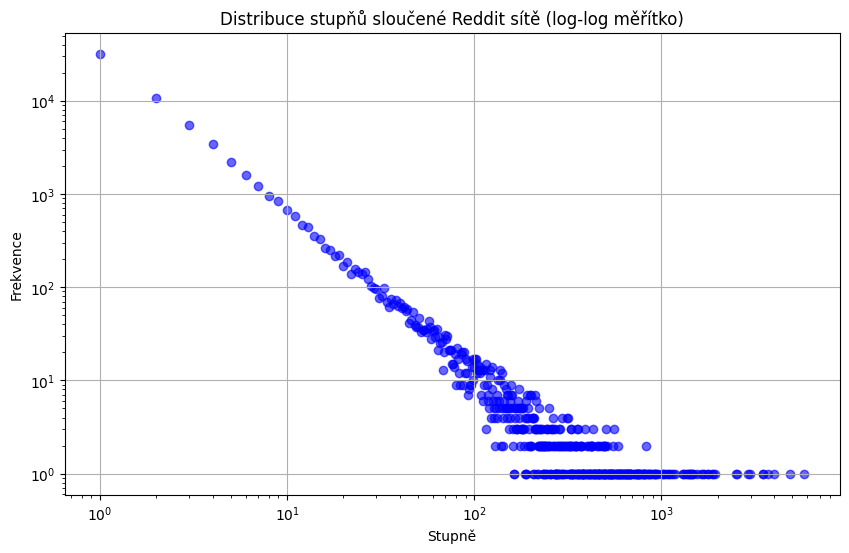

In [79]:
degrees = [degree for _, degree in G_merged.degree()] # pyright: ignore[reportCallIssue]
 
degree_counts = Counter(degrees)
deg, freq = zip(*sorted(degree_counts.items()))

plt.figure(figsize=(10, 6))
plt.scatter(deg, freq, alpha=0.6, color='blue')
plt.title(label='Distribuce stupňů sloučené Reddit sítě (log-log měřítko)')
plt.xlabel('Stupně')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(PLOTS_SAVE_PATH / 'reddit_degree_distribution.png', dpi=300)
plt.show()

### Distribuce stupňů uzlů v v lineárním měřítku

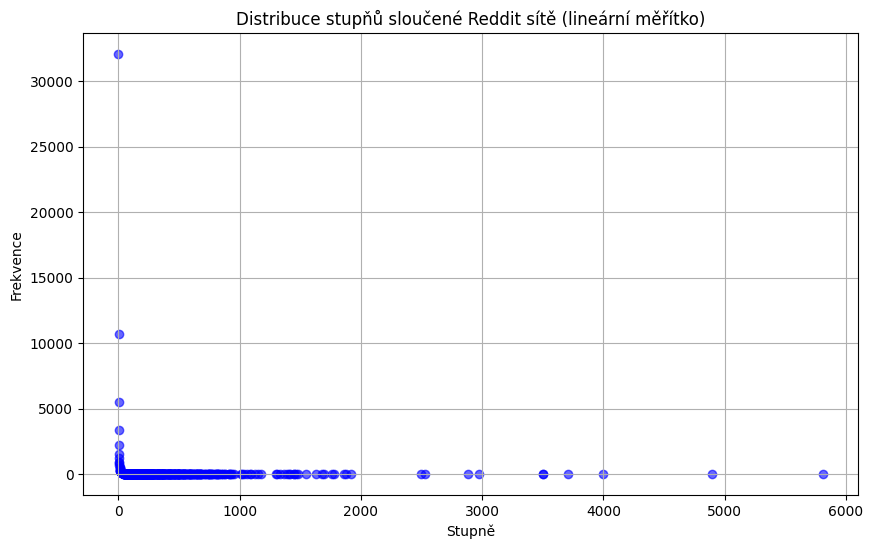

In [80]:
plt.figure(figsize=(10, 6))
plt.scatter(deg, freq, alpha=0.6, color='blue')
plt.title('Distribuce stupňů sloučené Reddit sítě (lineární měřítko)')
plt.xlabel('Stupně')
plt.ylabel('Frekvence')
plt.yscale('linear')
plt.xscale('linear')
plt.grid(True)
plt.savefig(PLOTS_SAVE_PATH / 'reddit_degree_distribution_linear.png', dpi=300)
plt.show()

### Velikosti komponent

In [81]:
component_size_counts = Counter(len(c) for c in nx.weakly_connected_components(G_merged))
component_sizes, component_freqs = zip(*sorted(component_size_counts.items()))

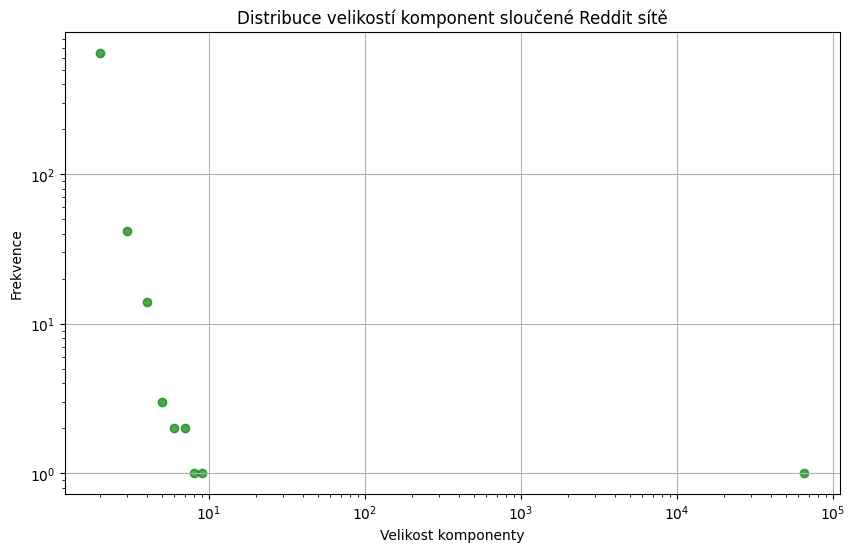

In [82]:
plt.figure(figsize=(10, 6))
plt.scatter(component_sizes, component_freqs, alpha=0.7, color='green')
plt.title('Distribuce velikostí komponent sloučené Reddit sítě')
plt.xlabel('Velikost komponenty')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(PLOTS_SAVE_PATH / 'reddit_component_size_distribution.png', dpi=300)
plt.show()

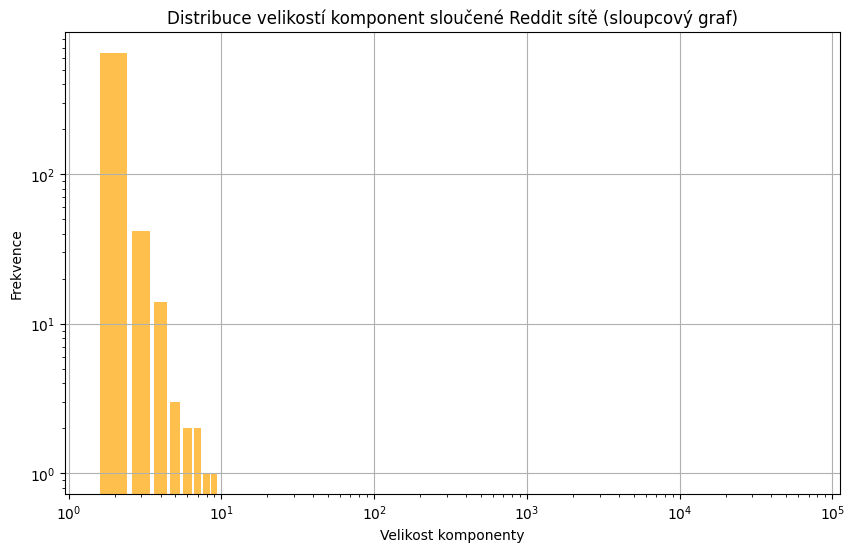

In [83]:
plt.figure(figsize=(10, 6))
plt.bar(component_sizes, component_freqs, color='orange', alpha=0.7)
plt.title('Distribuce velikostí komponent sloučené Reddit sítě (sloupcový graf)')
plt.xlabel('Velikost komponenty')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(PLOTS_SAVE_PATH / 'reddit_component_size_distribution_bar.png', dpi=300)
plt.show()

### Centrality top uzlů 

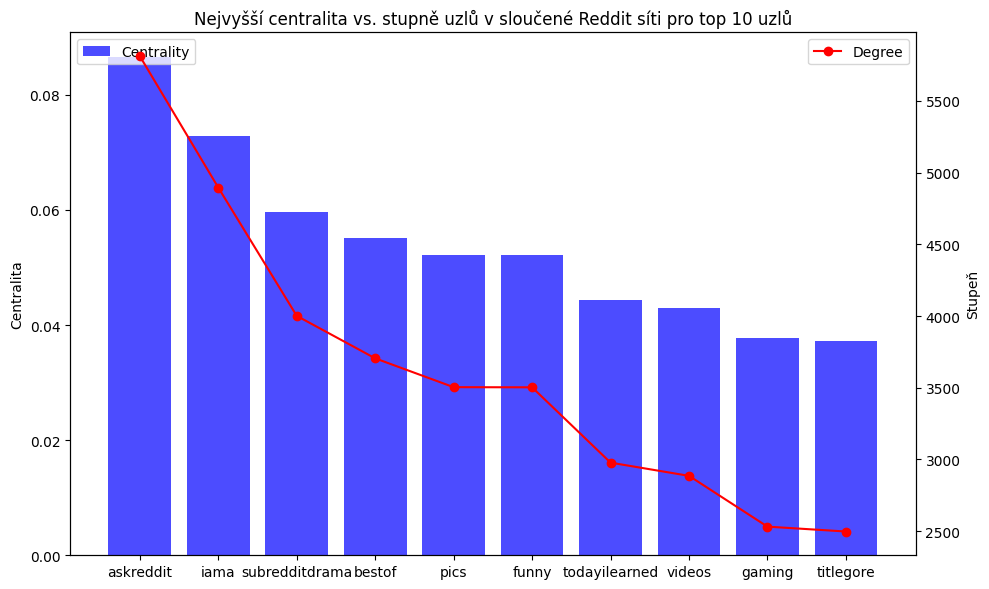

In [84]:
top10 = sorted(nx.degree_centrality(G_merged).items(), key=lambda x: x[1], reverse=True)[:10]
nodes, centralities = zip(*top10)
degrees = [G_merged.degree(n) for n in nodes]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.bar(nodes, centralities, label='Centrality', alpha=0.7, color='blue')
ax2.plot(nodes, degrees, label='Degree', color='red', marker='o')

ax1.set_ylabel('Centralita')
ax2.set_ylabel('Stupeň')

ax1.set_title('Nejvyšší centralita vs. stupně uzlů v sloučené Reddit síti pro top 10 uzlů')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_centrality_vs_degree.png', dpi=300)
plt.show()

### Scatterploty různých statistik

Tady pěkně vyplývá korelace mezi jednotlivými vlastnostmi sítě, například mezi počtem uzlů a hran, nebo mezi průměrnou délkou cest a shlukovacím koeficientem.

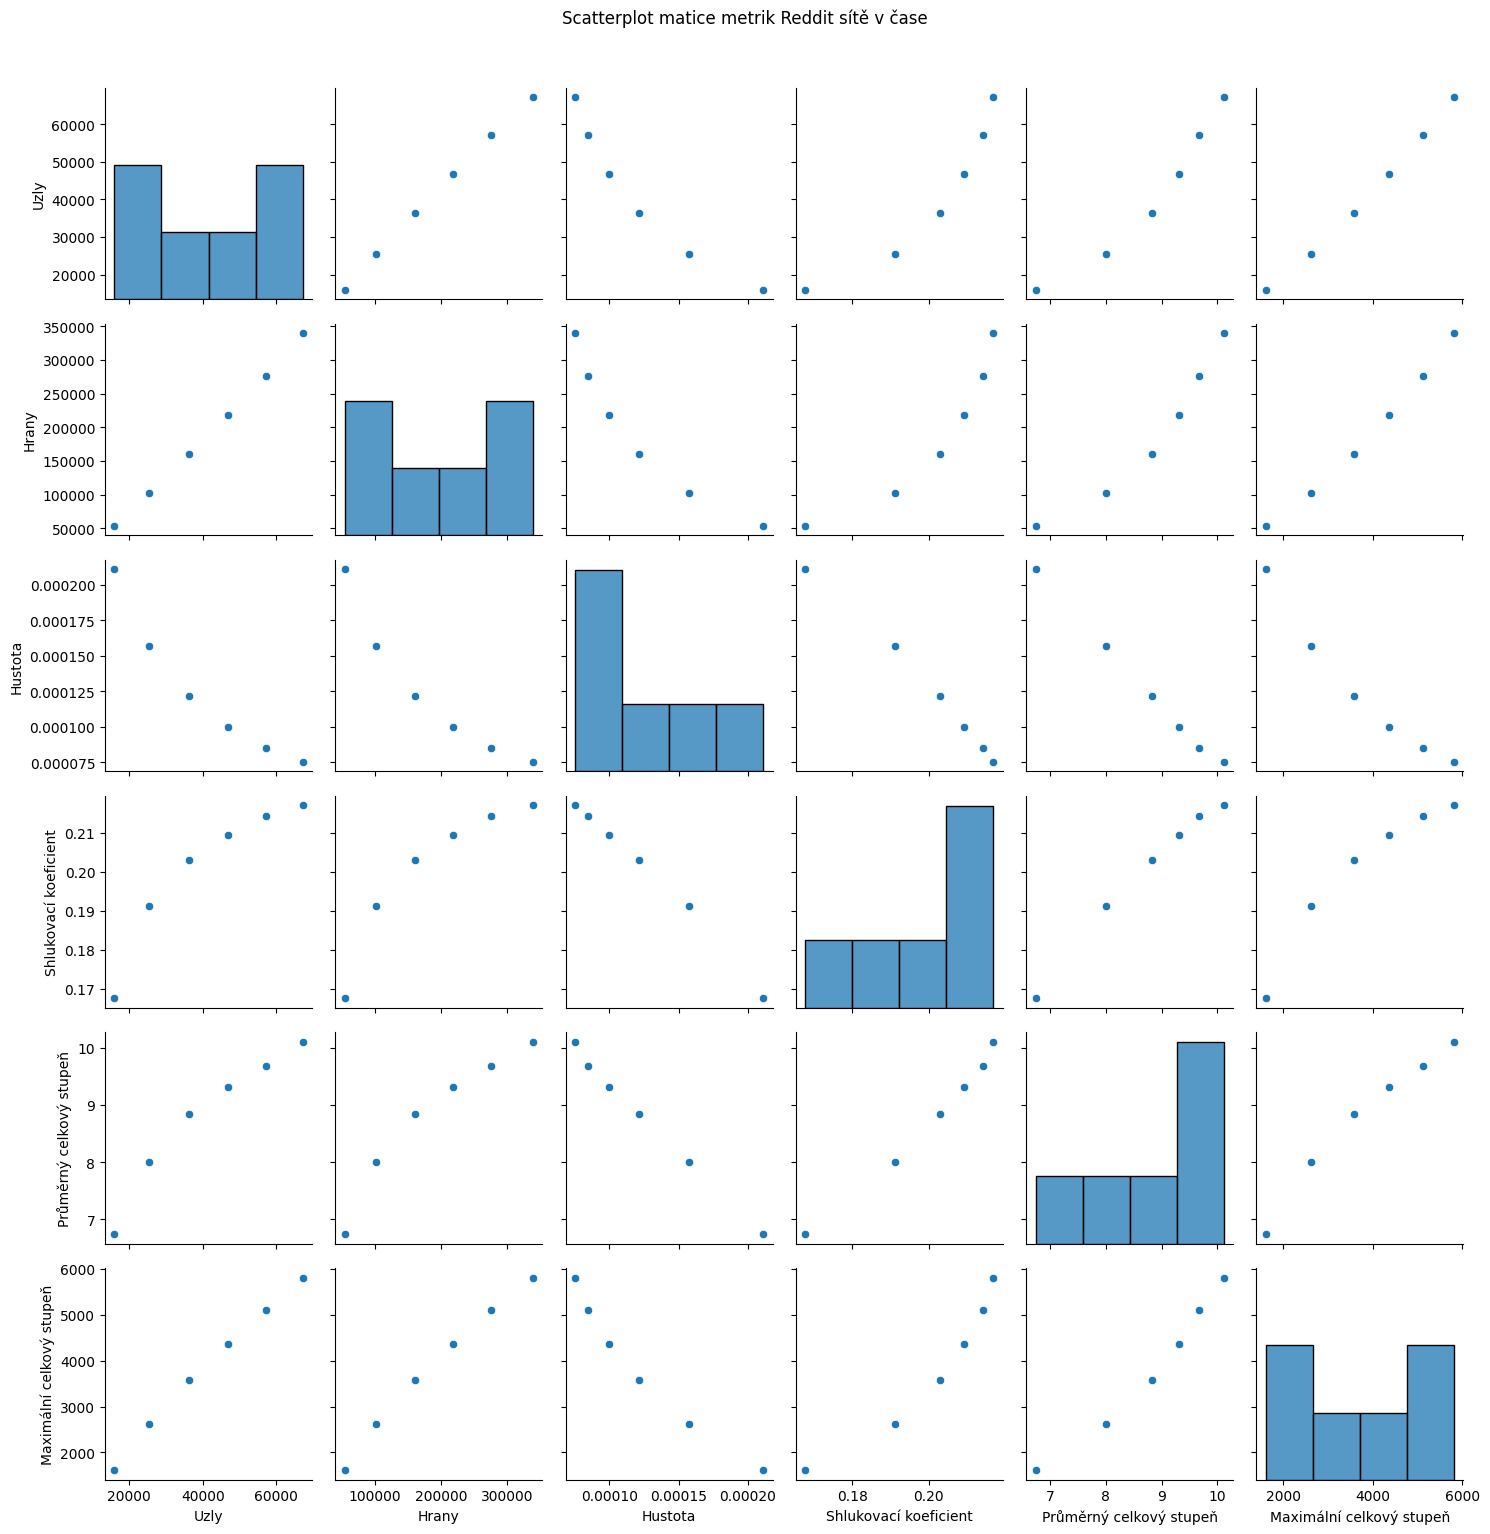

In [85]:
metrics = ['Nodes', 'Edges', 'Density', 'Clustering Coefficient', 'Average Total Degree', 'Max Total Degree']

metrics_czech = {
    'Nodes': 'Uzly',
    'Edges': 'Hrany',
    'Density': 'Hustota',
    'Clustering Coefficient': 'Shlukovací koeficient',
    'Average Total Degree': 'Průměrný celkový stupeň',
    'Max Total Degree': 'Maximální celkový stupeň'
}

df_plot = df_timestamp_stats[metrics].rename(columns=metrics_czech)
sns.pairplot(df_plot)
plt.suptitle('Scatterplot matice metrik Reddit sítě v čase', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_scatter_matrix.png', dpi=300)
plt.show()

### Dsitribuce shlukovacího koeficientu

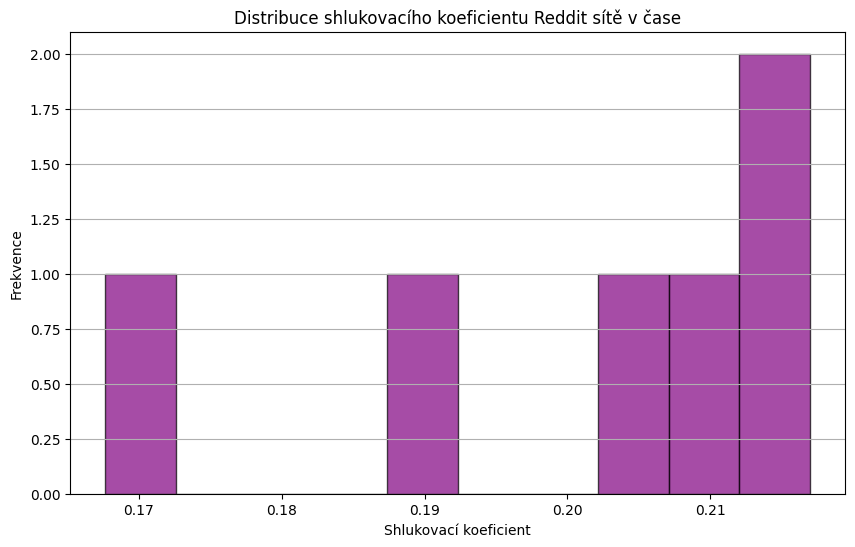

In [110]:
plt.figure(figsize=(10, 6))
plt.hist(df_timestamp_stats['Clustering Coefficient'], bins=10, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribuce shlukovacího koeficientu Reddit sítě v čase')
plt.xlabel('Shlukovací koeficient')
plt.ylabel('Frekvence')
plt.grid(True, axis='y')
plt.savefig(PLOTS_SAVE_PATH / 'reddit_clustering_coefficient_distribution.png', dpi=300)
plt.show()

### Průměrný shlukovací koeficient podle stupně uzlů

In [87]:
G = G_largest_undirected  # we will analyze the largest connected component

degrees = dict(G.degree())
clustering = nx.clustering(G)

degree_clustering = {}
for node, deg in degrees.items():
    degree_clustering.setdefault(deg, []).append(clustering[node]) #   type: ignore

avg_clustering_by_degree = {deg: np.mean(vals) for deg, vals in degree_clustering.items()}

deg_vals, clustering_vals = zip(*sorted(avg_clustering_by_degree.items()))

# Remove degree 1 from the plot since it's often an outlier
deg_clust = [(deg, clust) for deg, clust in zip(deg_vals, clustering_vals) if deg != 1]
deg_vals_filtered, clustering_vals_filtered = zip(*deg_clust)

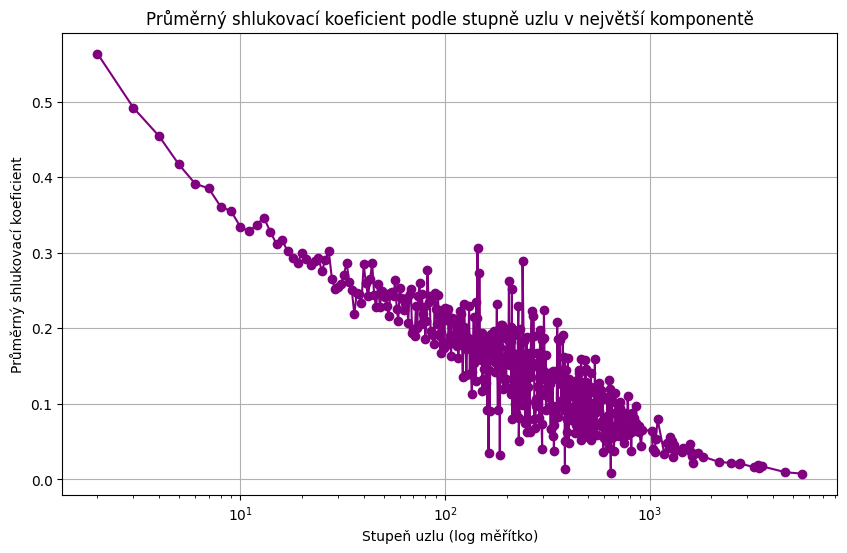

In [88]:
plt.figure(figsize=(10, 6))
plt.plot(deg_vals_filtered, clustering_vals_filtered, marker='o', linestyle='-', color='purple')
plt.xscale('log')
plt.xlabel('Stupeň uzlu (log měřítko)')
plt.ylabel('Průměrný shlukovací koeficient')
plt.title('Průměrný shlukovací koeficient podle stupně uzlu v největší komponentě')
plt.grid(True)
plt.savefig(PLOTS_SAVE_PATH / 'reddit_avg_clustering_by_degree.png', dpi=300)
plt.show()

## Vizualizace spojené s časem

### Vývoj kumulativního počtu uzlů v čase

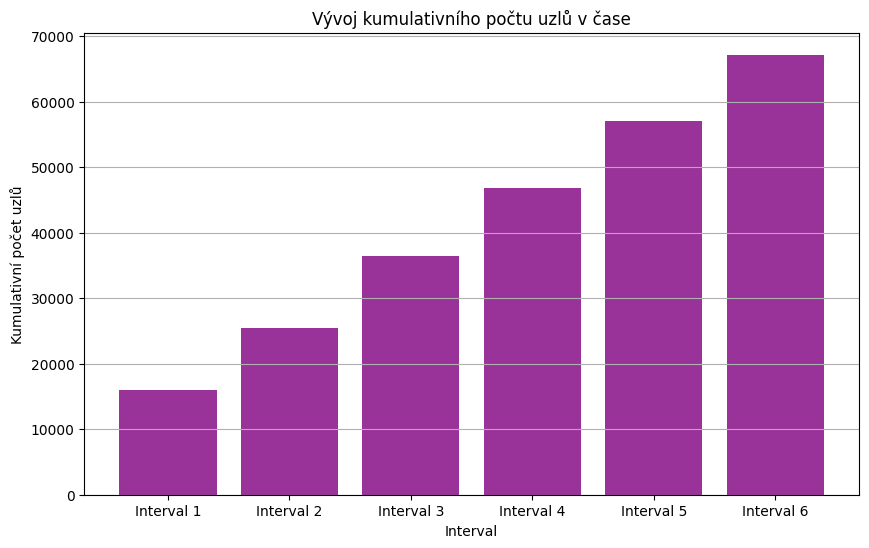

In [89]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Cumulative Nodes'], color='purple', alpha=0.8)
plt.title('Vývoj kumulativního počtu uzlů v čase')
plt.xlabel('Interval')
plt.ylabel('Kumulativní počet uzlů')
plt.grid(True, axis='y')
plt.savefig(PLOTS_SAVE_PATH / 'reddit_cumulative_nodes_bar.png', dpi=300)
plt.show()

### Vývoj počtu uzlů v jednotlivých časových intervalech

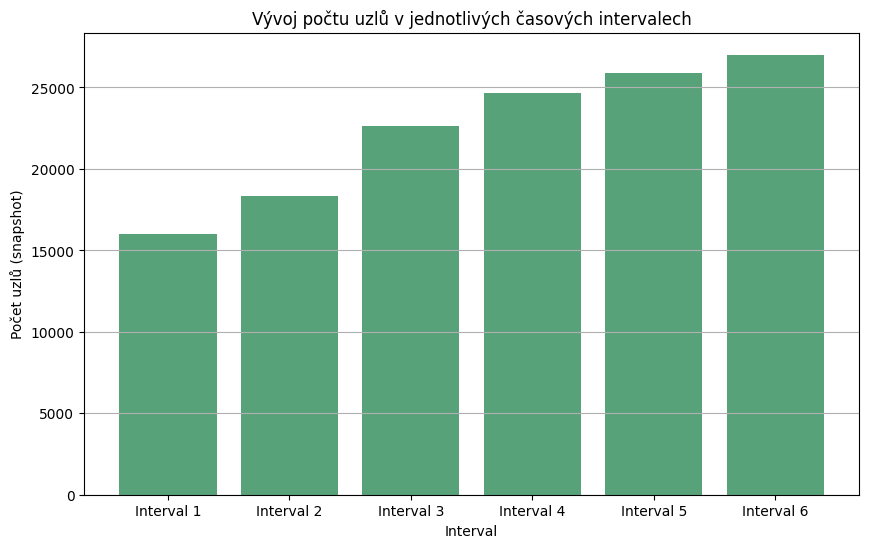

In [90]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Nodes'], color='seagreen', alpha=0.8)
plt.title('Vývoj počtu uzlů v jednotlivých časových intervalech')
plt.xlabel('Interval')
plt.ylabel('Počet uzlů (snapshot)')
plt.grid(True, axis='y')
plt.savefig(PLOTS_SAVE_PATH / 'reddit_snapshot_nodes_bar.png', dpi=300)
plt.show()

### Vývoj kumulativního počtu hran v čase

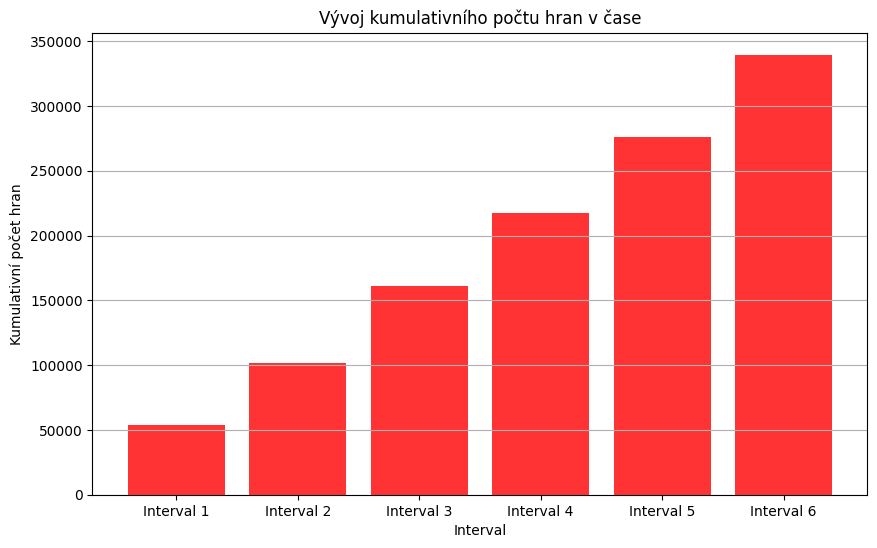

In [91]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Cumulative Edges'], color='red', alpha=0.8)
plt.title('Vývoj kumulativního počtu hran v čase')
plt.xlabel('Interval')
plt.ylabel('Kumulativní počet hran')
plt.grid(True, axis='y')
plt.savefig(PLOTS_SAVE_PATH / 'reddit_cumulative_edges_bar.png', dpi=300)
plt.show()

### Vývoj počtu uzlů v jednotlivých časových intervalech

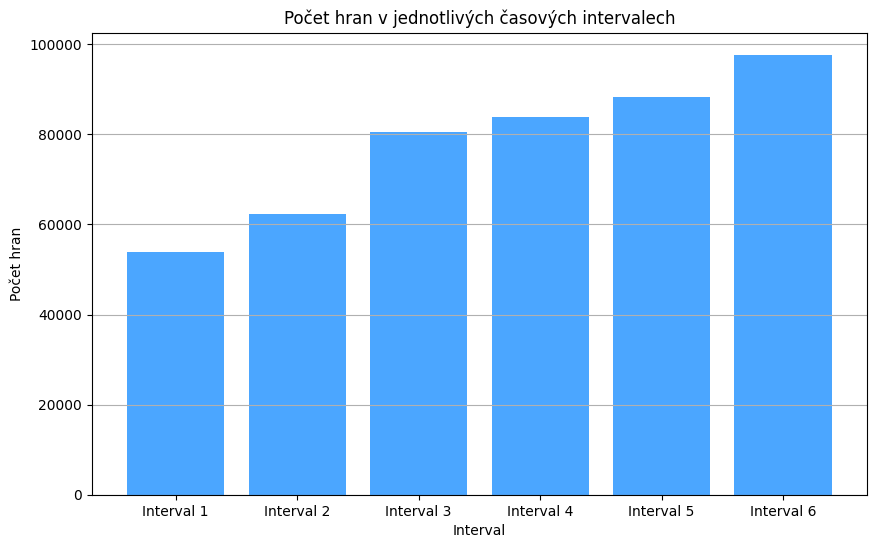

In [92]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Edges'], color='dodgerblue', alpha=0.8)
plt.title('Počet hran v jednotlivých časových intervalech')
plt.xlabel('Interval')
plt.ylabel('Počet hran')
plt.grid(True, axis='y')
plt.savefig(PLOTS_SAVE_PATH / 'reddit_edges_snapshot_bar.png', dpi=300)
plt.show()

### Průměrná nejkratší cesta a shlukovací koeficient v čase

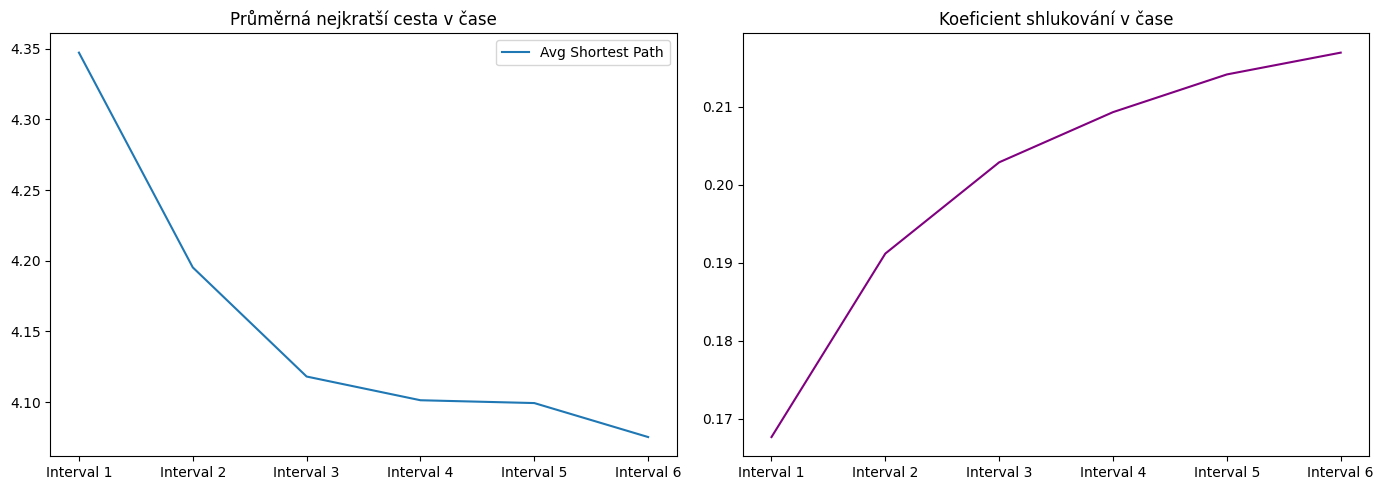

In [93]:
# First row (2 plots)
fig1, axs1 = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Average shortest path & diameter
axs1[0].plot(df_timestamp_stats['Interval'], df_timestamp_stats['Average Shortest Path'], label='Avg Shortest Path')
axs1[0].set_title('Průměrná nejkratší cesta v čase')
axs1[0].legend()

# Subplot 2: Clustering coefficient
axs1[1].plot(df_timestamp_stats['Interval'], df_timestamp_stats['Clustering Coefficient'], color='purple')
axs1[1].set_title('Koeficient shlukování v čase')

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_mixed_stats_row1.png', dpi=300)
plt.show()

### Nové uzly a hrany v čase + komulativní růst uzlů a hran

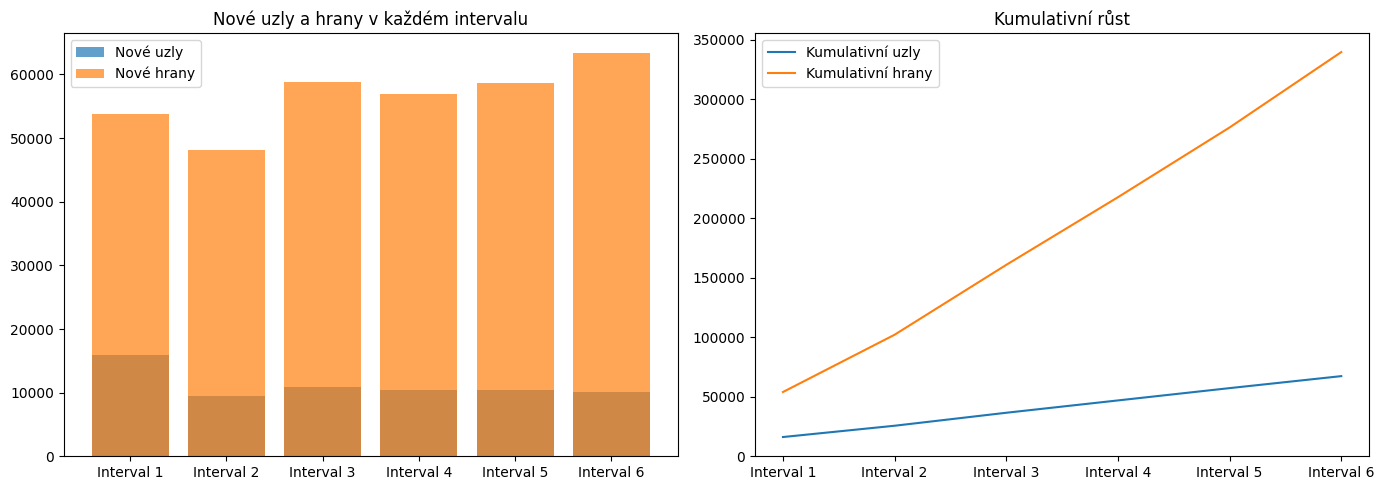

In [94]:
# Second row (2 plots)
fig2, axs2 = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 3: New nodes/edges
axs2[0].bar(df_stats['Interval'], df_stats['New Nodes'], label='Nové uzly', alpha=0.7)
axs2[0].bar(df_stats['Interval'], df_stats['New Edges'], label='Nové hrany', alpha=0.7)
axs2[0].set_title('Nové uzly a hrany v každém intervalu')
axs2[0].legend()

# Subplot 4: Cumulative nodes/edges
axs2[1].plot(df_stats['Interval'], df_stats['Cumulative Nodes'], label='Kumulativní uzly')
axs2[1].plot(df_stats['Interval'], df_stats['Cumulative Edges'], label='Kumulativní hrany')
axs2[1].set_title('Kumulativní růst')
axs2[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_mixed_stats_row2.png', dpi=300)
plt.show()

### Hustota a shlukovací koeficient v čase

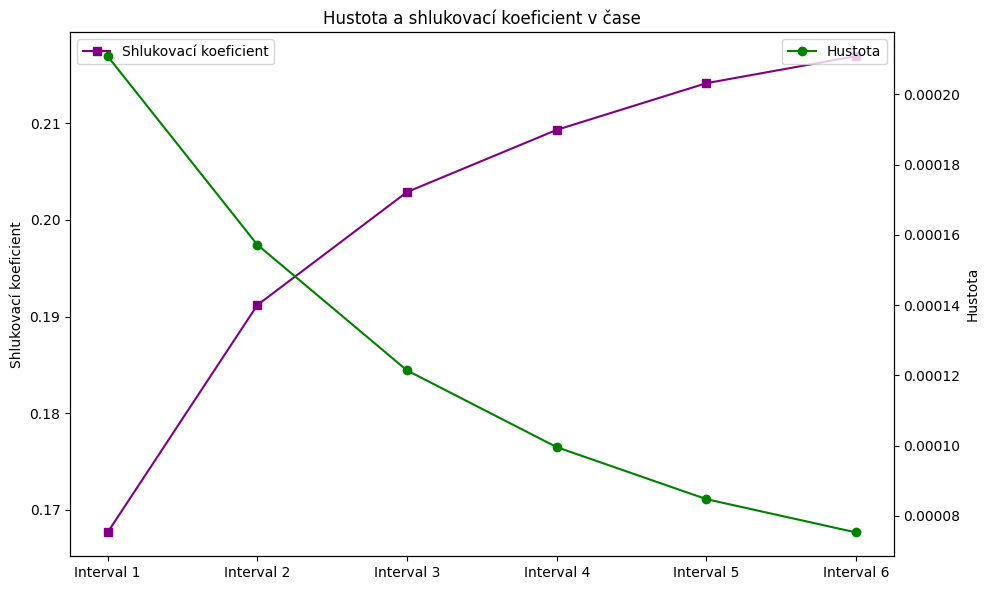

In [95]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Clustering Coefficient'], label='Shlukovací koeficient', marker='s', color='purple')
ax2.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Density'], label='Hustota', marker='o', color='green')

ax1.set_ylabel('Shlukovací koeficient')
ax2.set_ylabel('Hustota')

ax1.set_title('Hustota a shlukovací koeficient v čase')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_density_clustering.png', dpi=300)
plt.show()

### Největší komponenta a počet komponent v čase

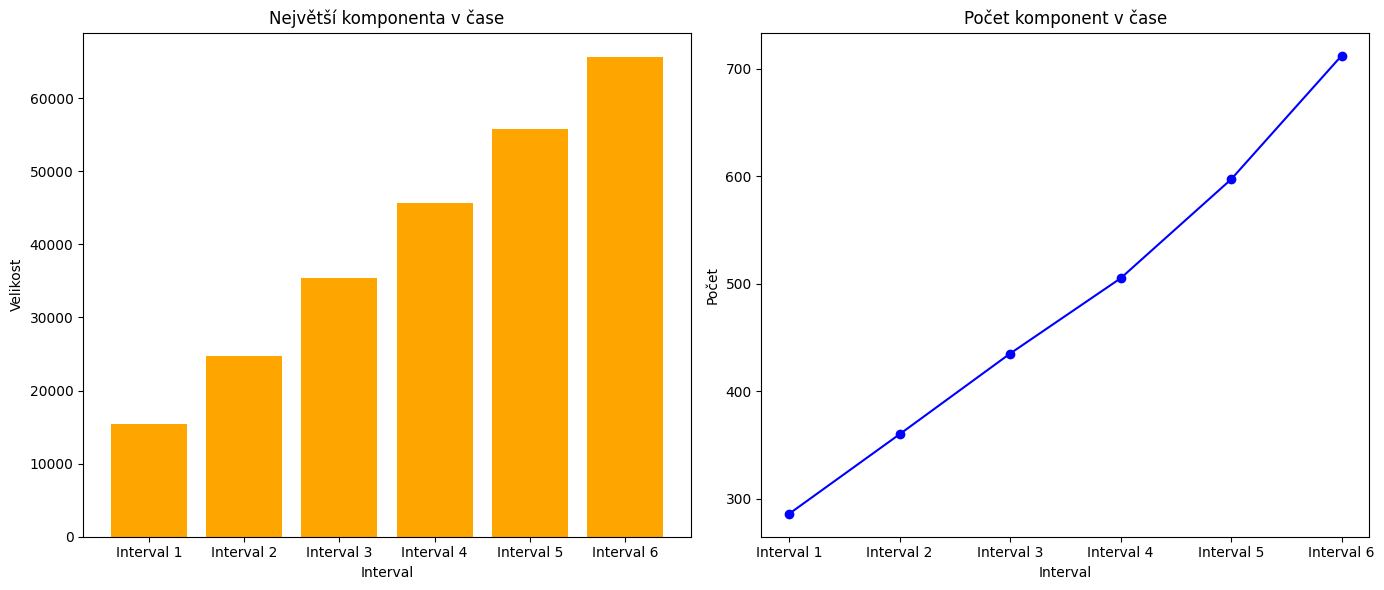

In [96]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].bar(df_timestamp_stats['Interval'], df_timestamp_stats['Size of Biggest Component'], color='orange')
axs[0].set_title('Největší komponenta v čase')
axs[0].set_xlabel('Interval')
axs[0].set_ylabel('Velikost')
axs[1].plot(df_timestamp_stats['Interval'], df_timestamp_stats['Number of Components'], marker='o', color='blue')
axs[1].set_title('Počet komponent v čase')
axs[1].set_xlabel('Interval')
axs[1].set_ylabel('Počet')
plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_component_evolution.png', dpi=300)
plt.show()

### Vývoj distribuce stupňů uzlů v čase

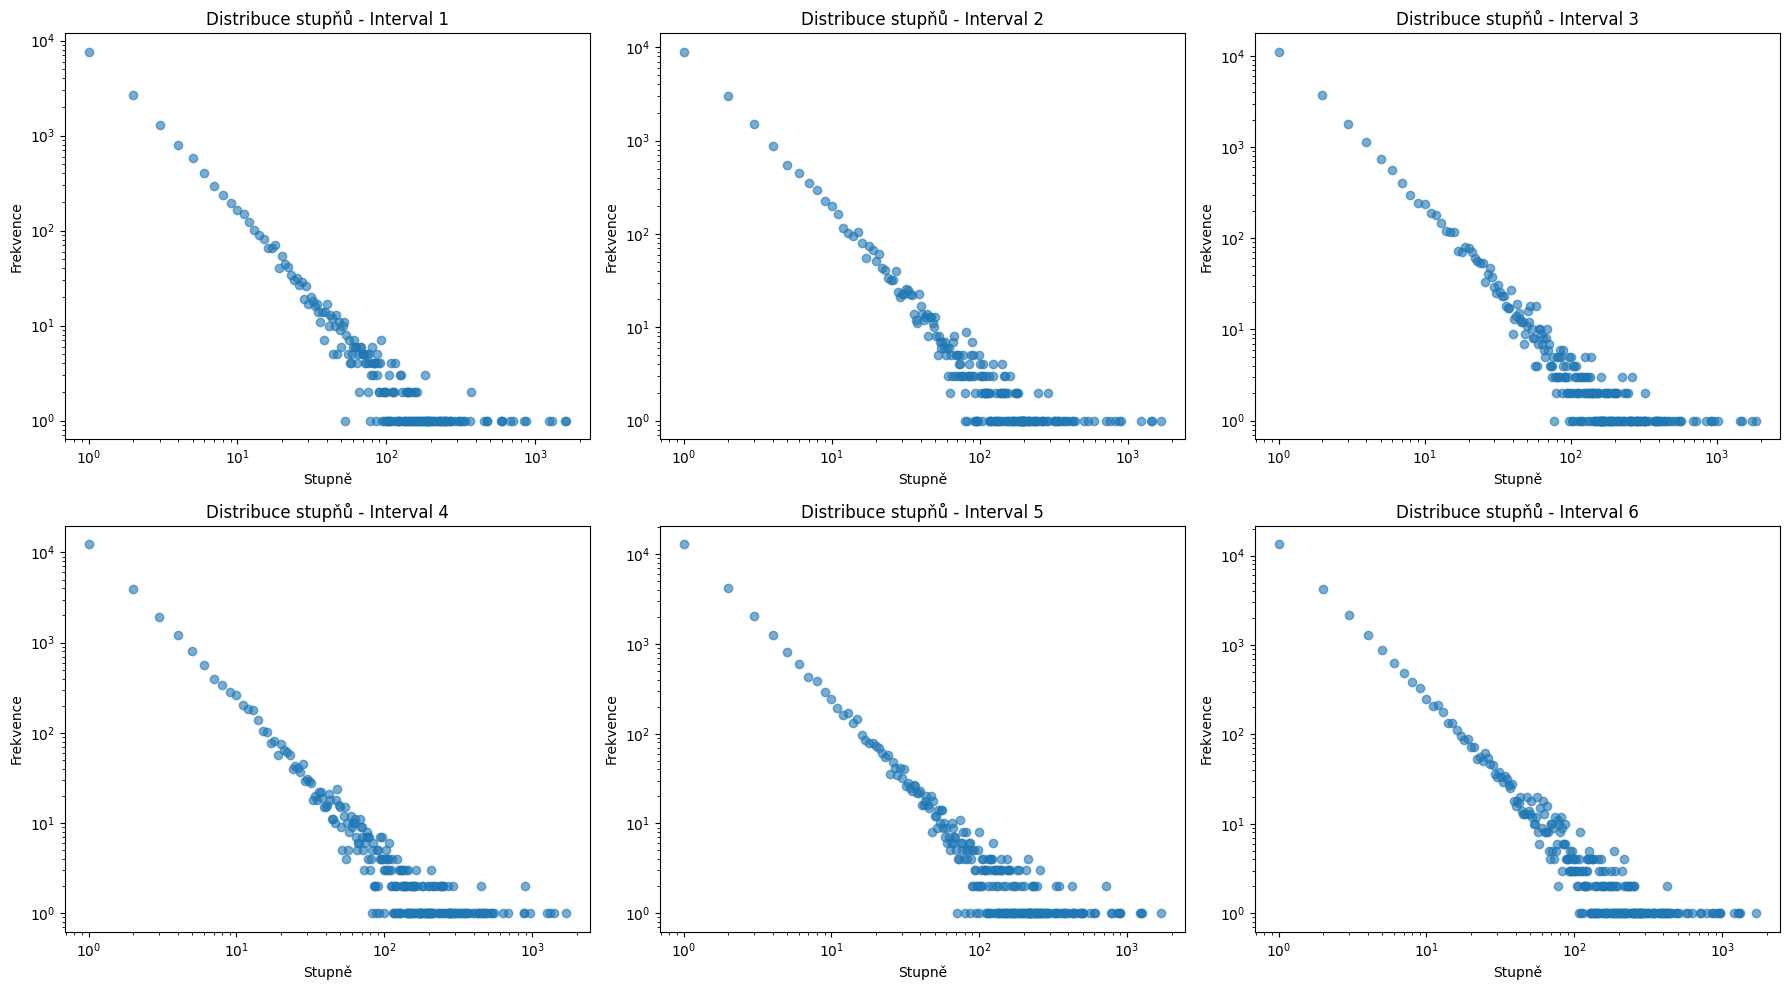

In [97]:
intervals = df_stats['Interval'].tolist()
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
for i, label in enumerate(intervals):
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_split = nx.from_pandas_edgelist(df_split, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT', create_using=nx.DiGraph()) # type: ignore
    degrees = [deg for _, deg in G_split.degree()]
    degree_counts = Counter(degrees)
    deg, freq = zip(*sorted(degree_counts.items()))
    ax = axs[i // 3, i % 3]
    ax.scatter(deg, freq, alpha=0.6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Distribuce stupňů - {label}')
    ax.set_xlabel('Stupně')
    ax.set_ylabel('Frekvence')
plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_degree_distribution_intervals.png', dpi=300)
plt.show()

### Společní sousedi v průběhu času

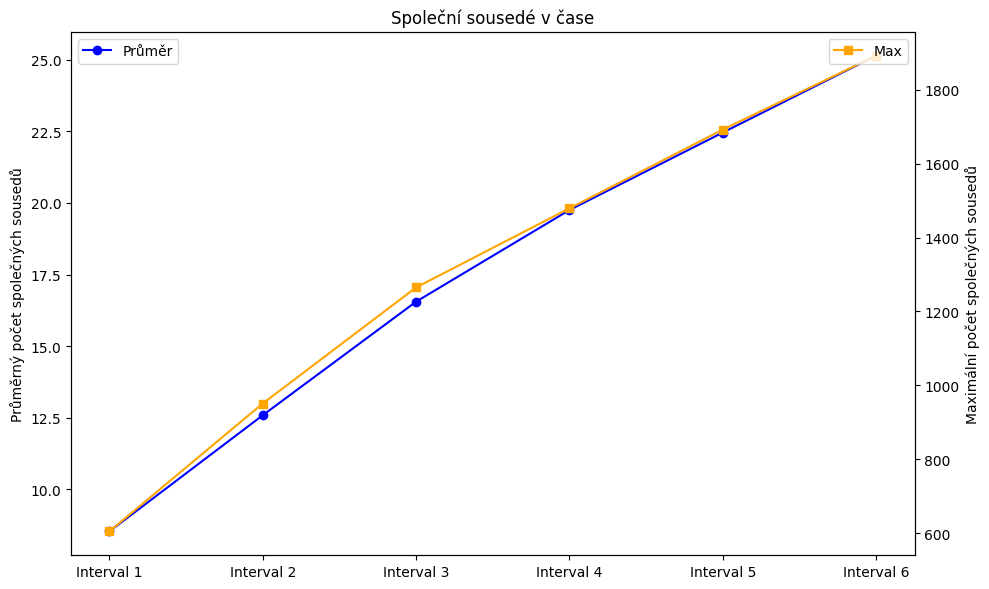

In [98]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Average Common Neighbors'], label='Průměr', marker='o', color='blue')
ax2.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Max Common Neighbors'], label='Max', marker='s', color='orange')

ax1.set_ylabel('Průměrný počet společných sousedů')
ax2.set_ylabel('Maximální počet společných sousedů')

ax1.set_title('Společní sousedé v čase')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xlabel('Interval')
plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_common_neighbors.png', dpi=300)
plt.show()

### Centralita top uzlů v čase

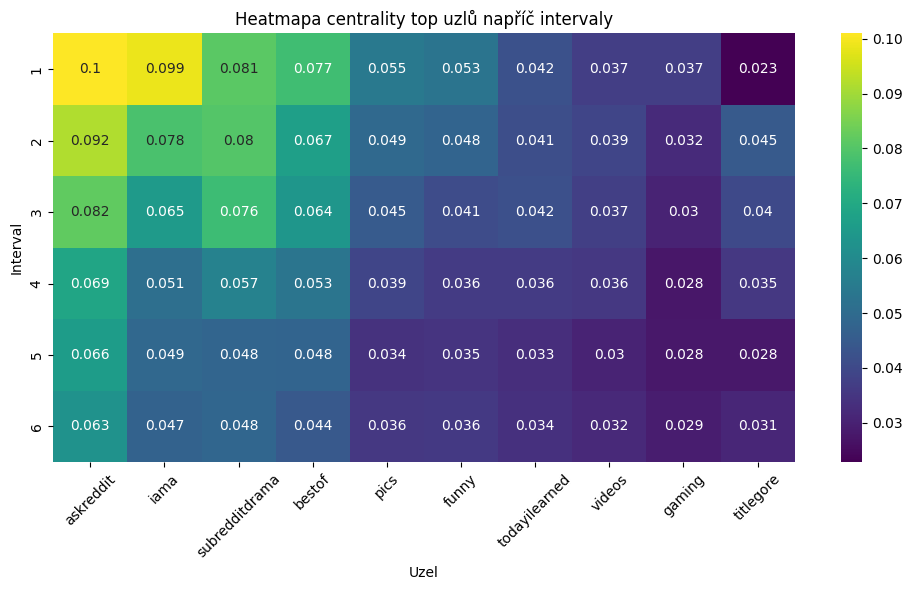

In [99]:
top_nodes = [n for n, _ in top10]
centrality_matrix = []
for i, label in enumerate(intervals):
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_split = nx.from_pandas_edgelist(df_split, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT', create_using=nx.DiGraph()) # type: ignore
    centrality = nx.degree_centrality(G_split)
    centrality_matrix.append([centrality.get(n, 0) for n in top_nodes])
plt.figure(figsize=(10, 6))
sns.heatmap(centrality_matrix, annot=True, xticklabels=top_nodes, yticklabels=[str(i+1) for i in range(len(intervals))], cmap='viridis')
plt.title('Heatmapa centrality top uzlů napříč intervaly')
plt.xlabel('Uzel')
plt.xticks(rotation=45)
plt.ylabel('Interval')
plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_centrality_heatmap.png', dpi=300)
plt.show()

### Porovnání nových uzlů a hran mezi časovými intervaly

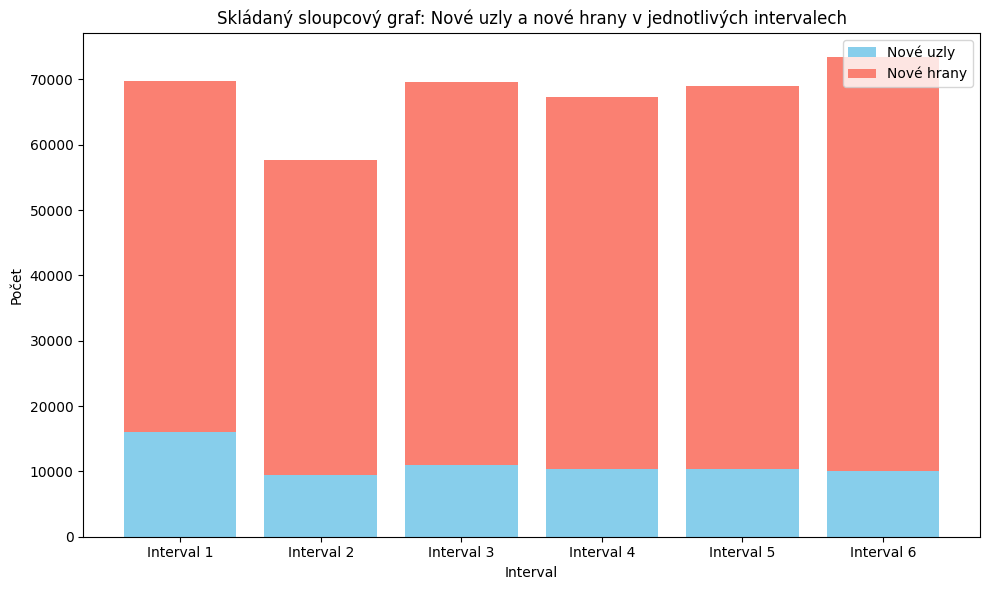

In [100]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['New Nodes'], label='Nové uzly', color='skyblue')
plt.bar(df_stats['Interval'], df_stats['New Edges'], bottom=df_stats['New Nodes'], label='Nové hrany', color='salmon')
plt.title('Skládaný sloupcový graf: Nové uzly a nové hrany v jednotlivých intervalech')
plt.xlabel('Interval')
plt.ylabel('Počet')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'reddit_stacked_new_nodes_edges.png', dpi=300)
plt.show()

## Vizualizace šíření vlivu

In [101]:
# Load all simulation results
si_df = pd.DataFrame(si_results)
sis_df = pd.DataFrame(sis_results) 
sir_df = pd.DataFrame(sir_results)
ic_df = pd.DataFrame(ic_results)

### Porovnání průměrného dosahu různých modelů


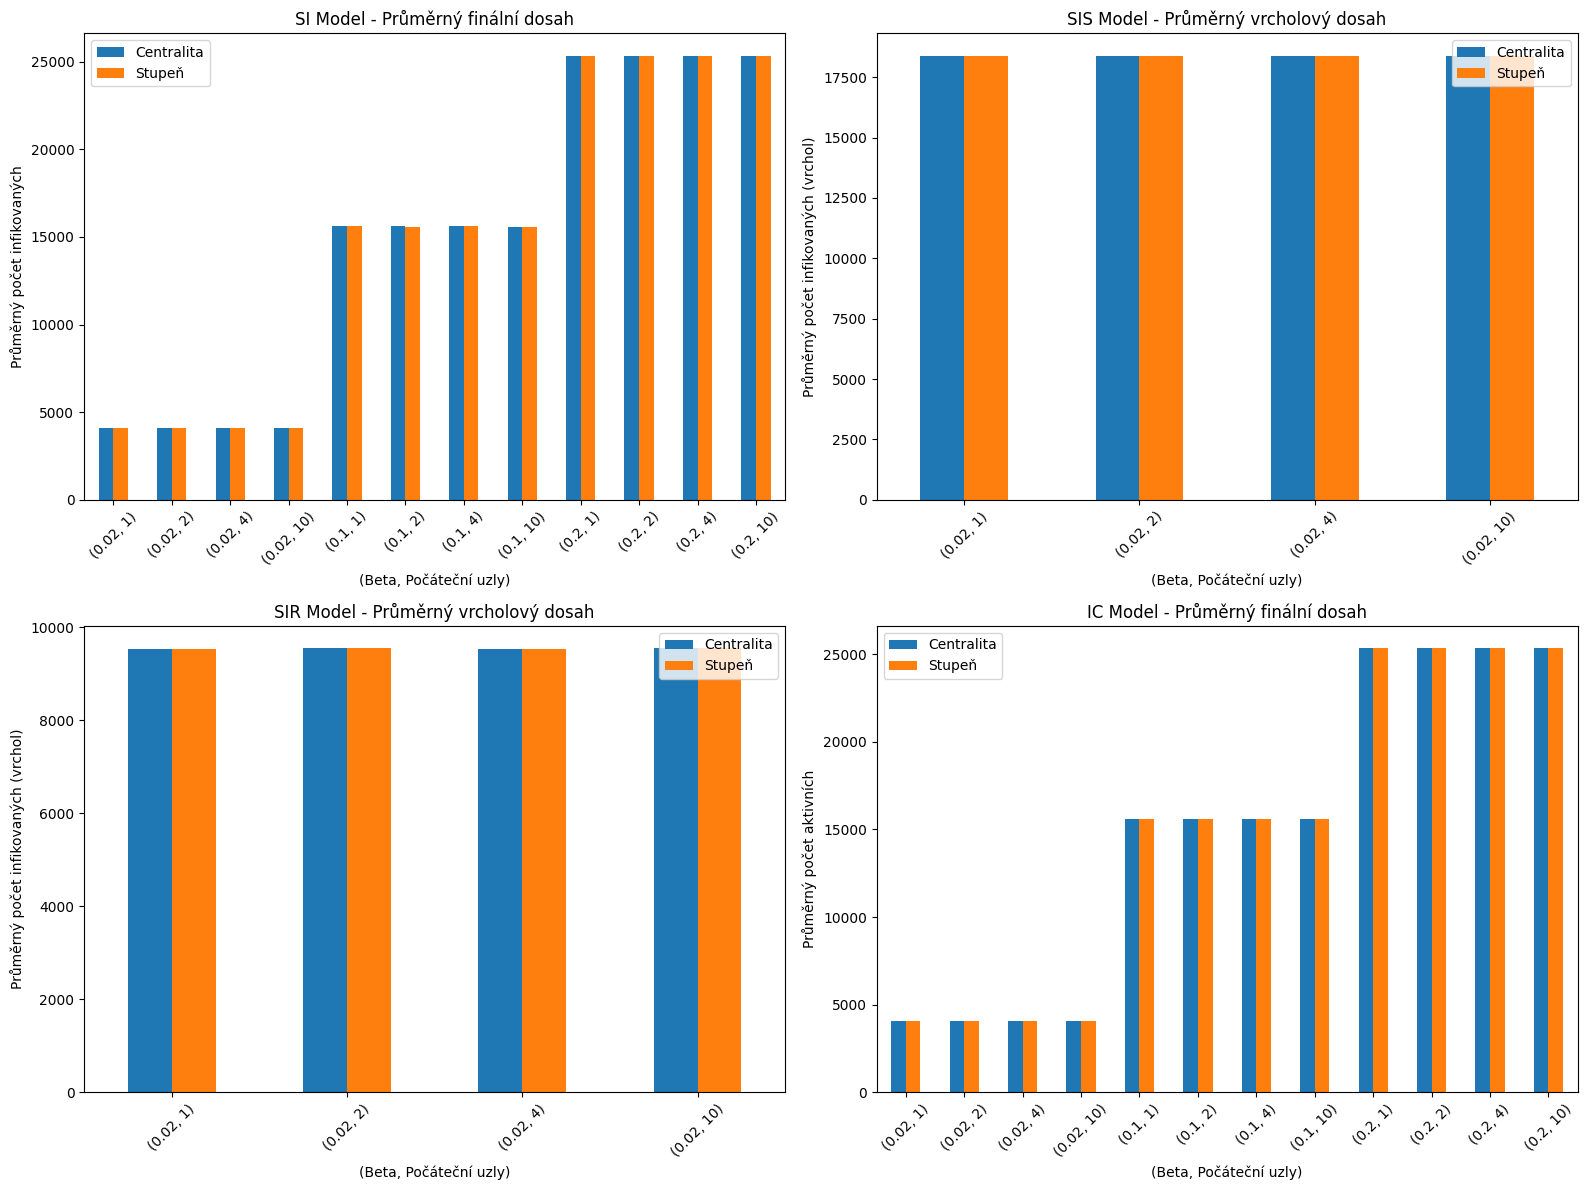

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# SI Model
si_pivot = si_df.pivot_table(index=['beta', 'num_initial_nodes'], columns='method', values='mean')
si_pivot.plot(kind='bar', ax=axes[0,0], title='SI Model - Průměrný finální dosah')
axes[0,0].set_xlabel('(Beta, Počáteční uzly)')
axes[0,0].set_ylabel('Průměrný počet infikovaných')
axes[0,0].legend(['Centralita', 'Stupeň'])
axes[0,0].tick_params(axis='x', rotation=45)

# SIS Model  
sis_pivot = sis_df.pivot_table(index=['beta', 'num_initial_nodes'], columns='method', values='mean')
sis_pivot.plot(kind='bar', ax=axes[0,1], title='SIS Model - Průměrný vrcholový dosah')
axes[0,1].set_xlabel('(Beta, Počáteční uzly)')
axes[0,1].set_ylabel('Průměrný počet infikovaných (vrchol)')
axes[0,1].legend(['Centralita', 'Stupeň'])
axes[0,1].tick_params(axis='x', rotation=45)

# SIR Model
sir_pivot = sir_df.pivot_table(index=['beta', 'num_initial_nodes'], columns='method', values='mean')
sir_pivot.plot(kind='bar', ax=axes[1,0], title='SIR Model - Průměrný vrcholový dosah')
axes[1,0].set_xlabel('(Beta, Počáteční uzly)')
axes[1,0].set_ylabel('Průměrný počet infikovaných (vrchol)')
axes[1,0].legend(['Centralita', 'Stupeň'])
axes[1,0].tick_params(axis='x', rotation=45)

# IC Model
ic_pivot = ic_df.pivot_table(index=['beta', 'num_initial_nodes'], columns='method', values='mean')
ic_pivot.plot(kind='bar', ax=axes[1,1], title='IC Model - Průměrný finální dosah')
axes[1,1].set_xlabel('(Beta, Počáteční uzly)')
axes[1,1].set_ylabel('Průměrný počet aktivních')
axes[1,1].legend(['Centralita', 'Stupeň'])
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'spreading_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Boxploty distribuce dosahu pro IC model

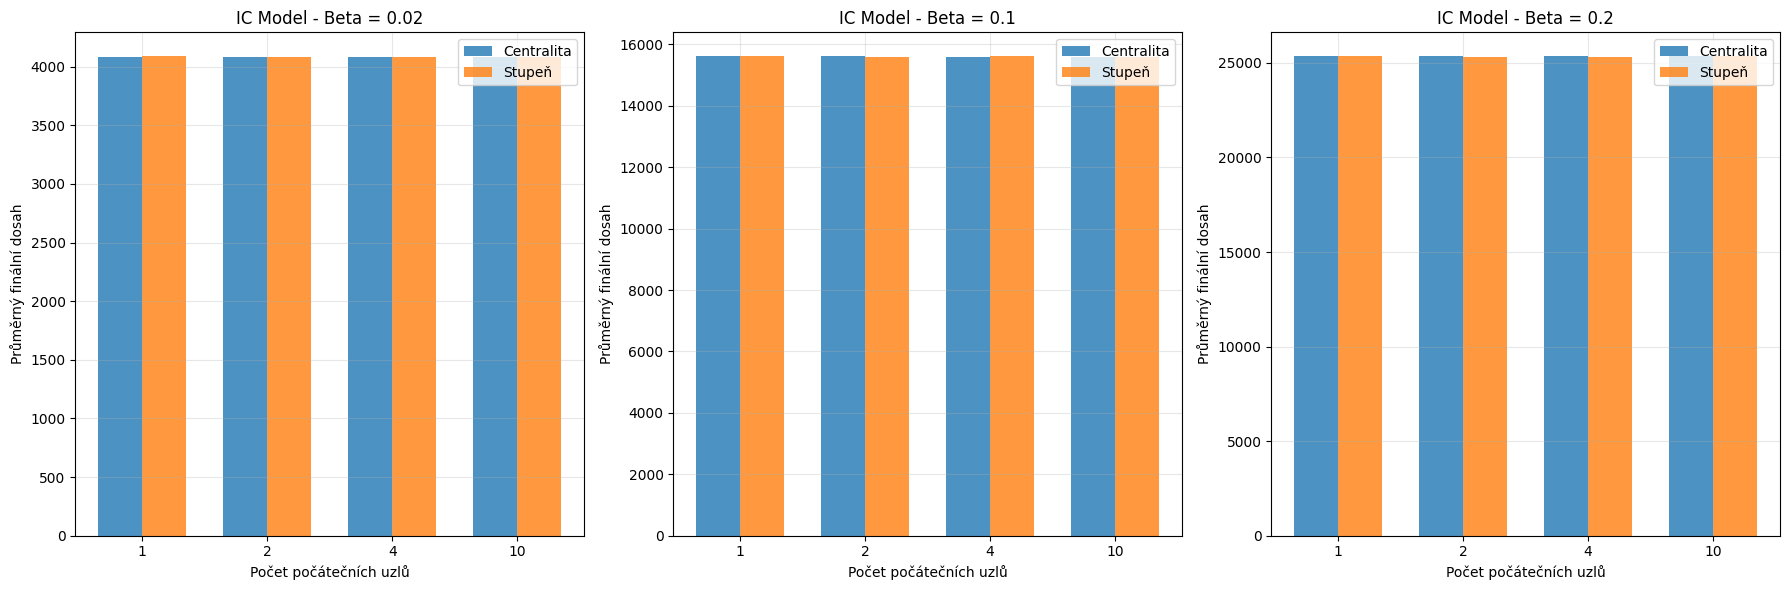

In [103]:
ic_long = ic_df.melt(id_vars=['method', 'beta', 'num_initial_nodes'], 
                    value_vars=['min', 'q1', 'median', 'q3', 'max', 'mean'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, beta in enumerate(sorted(ic_df['beta'].unique())):
    beta_data = ic_df[ic_df['beta'] == beta]
    
    centrality_means = beta_data[beta_data['method'] == 'centrality']['mean'].values
    degree_means = beta_data[beta_data['method'] == 'degree']['mean'].values
    
    x_pos = np.arange(len(beta_data['num_initial_nodes'].unique()))
    width = 0.35
    
    axes[i].bar(x_pos - width/2, centrality_means, width, label='Centralita', alpha=0.8)
    axes[i].bar(x_pos + width/2, degree_means, width, label='Stupeň', alpha=0.8)
    
    axes[i].set_title(f'IC Model - Beta = {beta}')
    axes[i].set_xlabel('Počet počátečních uzlů')
    axes[i].set_ylabel('Průměrný finální dosah')
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels(sorted(beta_data['num_initial_nodes'].unique()))
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'ic_model_detailed.png', dpi=300, bbox_inches='tight')
plt.show()


### Porovnání interval vs finální síť


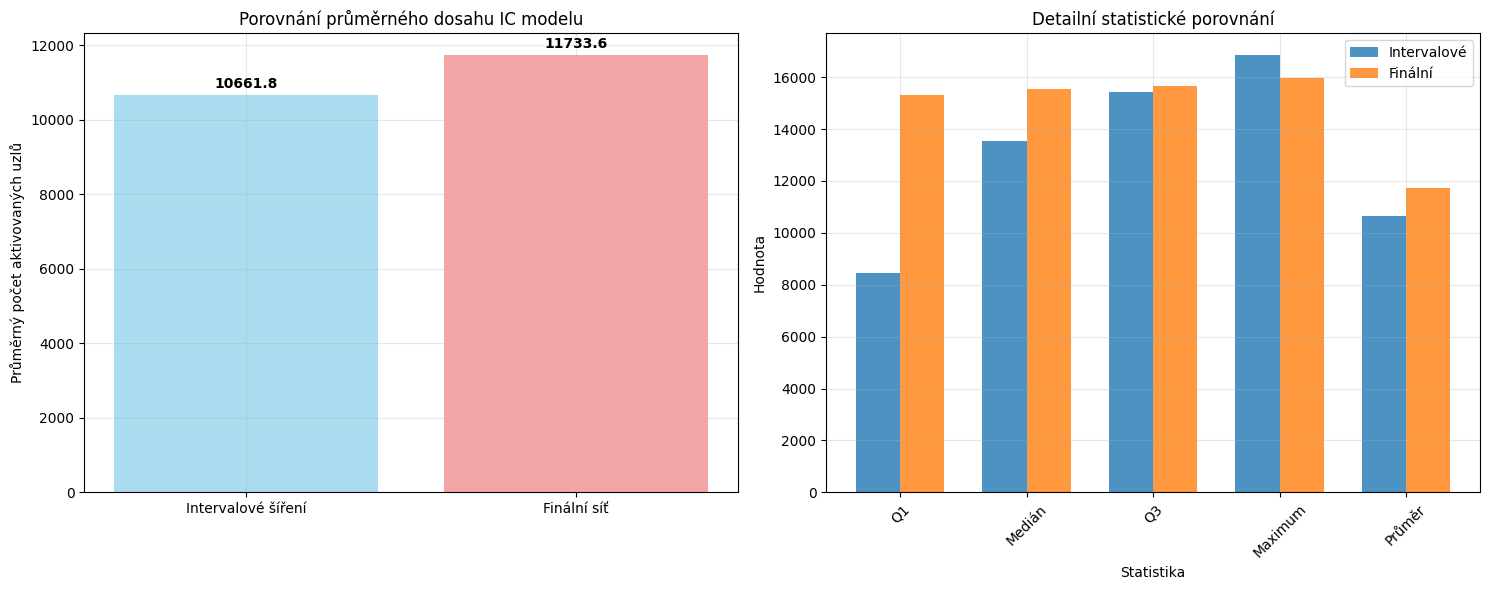

In [104]:
if 'ic_stats_df' in locals() and not ic_stats_df.empty:
    interval_row = ic_stats_df[ic_stats_df['type'] == 'interval'].iloc[0]
    final_row = ic_stats_df[ic_stats_df['type'] == 'final'].iloc[0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Comparison of means
    categories = ['Intervalové šíření', 'Finální síť']
    means = [interval_row['mean'], final_row['mean']]
    
    bars = ax1.bar(categories, means, color=['skyblue', 'lightcoral'], alpha=0.7)
    ax1.set_title('Porovnání průměrného dosahu IC modelu')
    ax1.set_ylabel('Průměrný počet aktivovaných uzlů')
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, mean in zip(bars, means):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(means)*0.01, 
                f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Statistical comparison (remove "Minimum")
    stats_comparison = pd.DataFrame({
        'Metrika': ['Q1', 'Medián', 'Q3', 'Maximum', 'Průměr'],
        'Intervalové': [interval_row['q1'], interval_row['median'], 
                       interval_row['q3'], interval_row['max'], interval_row['mean']],
        'Finální': [final_row['q1'], final_row['median'], 
                   final_row['q3'], final_row['max'], final_row['mean']]
    })
    
    x = np.arange(len(stats_comparison))
    width = 0.35
    
    ax2.bar(x - width/2, stats_comparison['Intervalové'], width, label='Intervalové', alpha=0.8)
    ax2.bar(x + width/2, stats_comparison['Finální'], width, label='Finální', alpha=0.8)
    
    ax2.set_title('Detailní statistické porovnání')
    ax2.set_xlabel('Statistika')
    ax2.set_ylabel('Hodnota')
    ax2.set_xticks(x)
    ax2.set_xticklabels(stats_comparison['Metrika'], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(PLOTS_SAVE_PATH / 'interval_vs_final_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


### Vliv beta parametru na různé modely


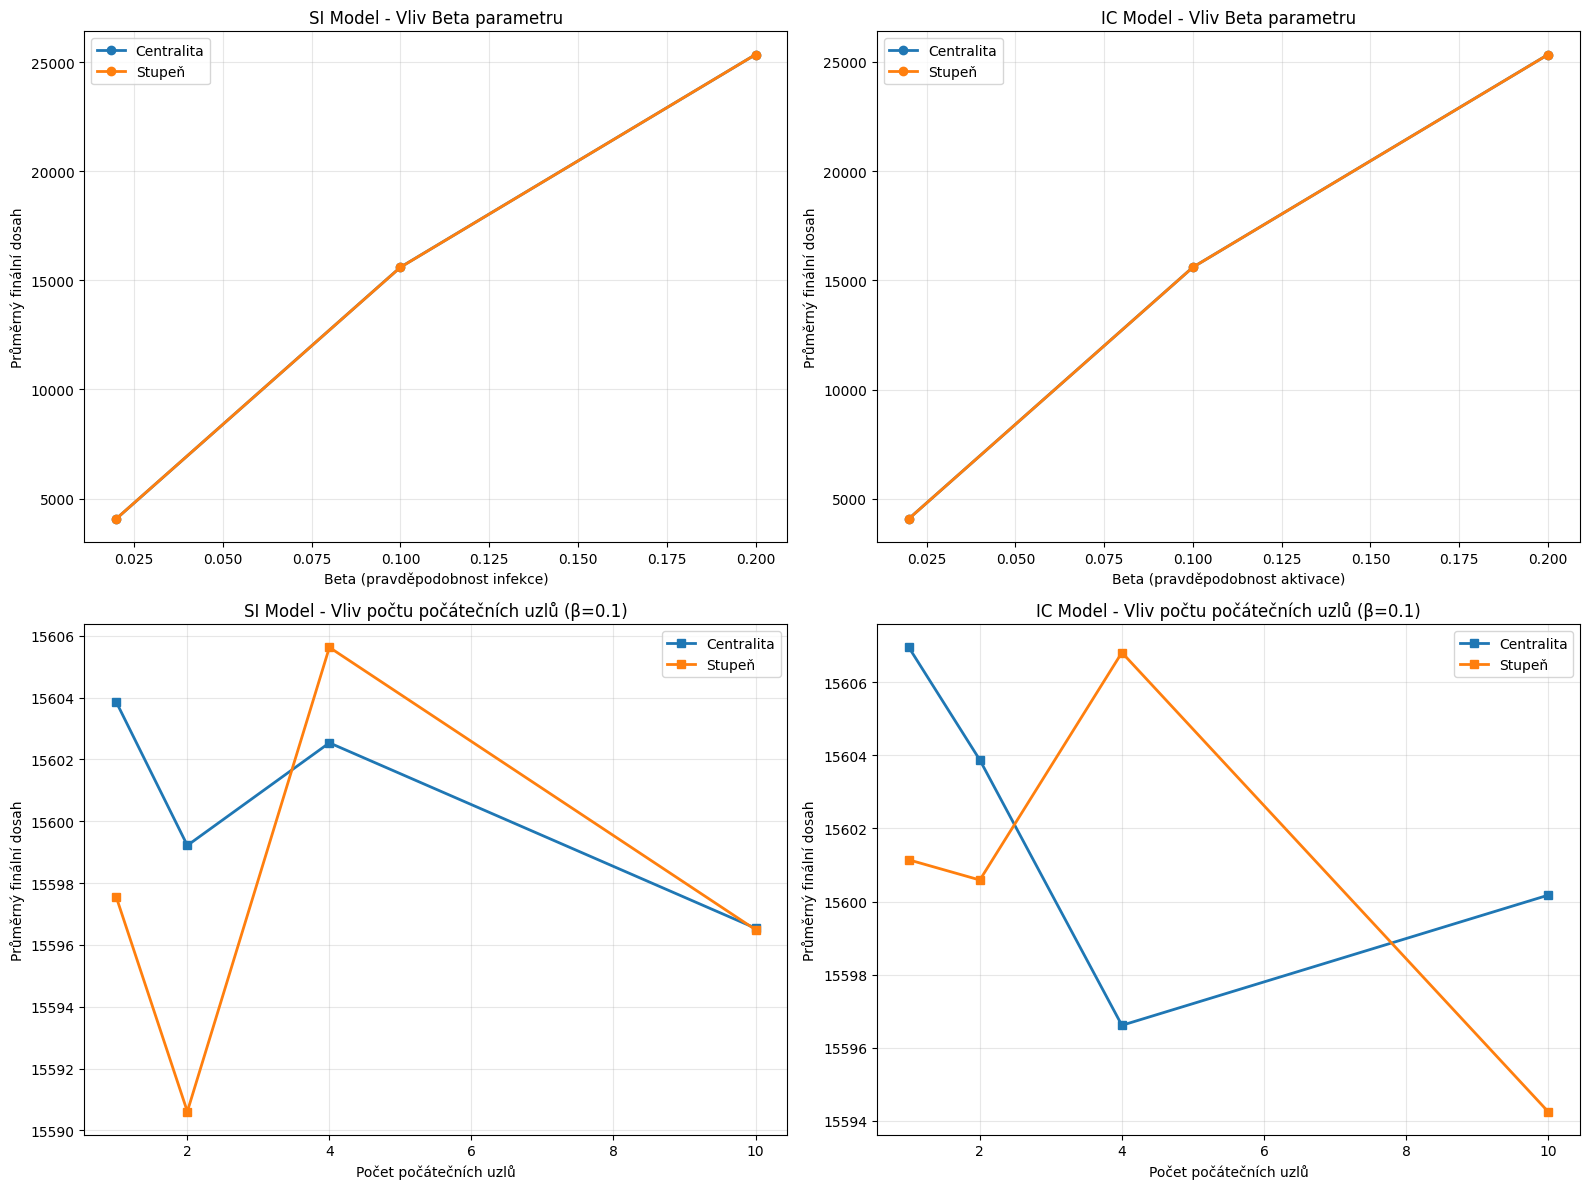

In [105]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# SI model - effect of beta
si_beta_effect = si_df.groupby(['beta', 'method'])['mean'].mean().unstack()
si_beta_effect.plot(ax=axes[0,0], marker='o', linewidth=2)
axes[0,0].set_title('SI Model - Vliv Beta parametru')
axes[0,0].set_xlabel('Beta (pravděpodobnost infekce)')
axes[0,0].set_ylabel('Průměrný finální dosah')
axes[0,0].legend(['Centralita', 'Stupeň'])
axes[0,0].grid(True, alpha=0.3)

# IC model - effect of beta  
ic_beta_effect = ic_df.groupby(['beta', 'method'])['mean'].mean().unstack()
ic_beta_effect.plot(ax=axes[0,1], marker='o', linewidth=2)
axes[0,1].set_title('IC Model - Vliv Beta parametru')
axes[0,1].set_xlabel('Beta (pravděpodobnost aktivace)')
axes[0,1].set_ylabel('Průměrný finální dosah')
axes[0,1].legend(['Centralita', 'Stupeň'])
axes[0,1].grid(True, alpha=0.3)

# Effect of initial nodes - SI model
si_nodes_effect = si_df[si_df['beta'] == 0.1].groupby(['num_initial_nodes', 'method'])['mean'].mean().unstack()
si_nodes_effect.plot(ax=axes[1,0], marker='s', linewidth=2)
axes[1,0].set_title('SI Model - Vliv počtu počátečních uzlů (β=0.1)')
axes[1,0].set_xlabel('Počet počátečních uzlů')
axes[1,0].set_ylabel('Průměrný finální dosah')
axes[1,0].legend(['Centralita', 'Stupeň'])
axes[1,0].grid(True, alpha=0.3)

# Effect of initial nodes - IC model
ic_nodes_effect = ic_df[ic_df['beta'] == 0.1].groupby(['num_initial_nodes', 'method'])['mean'].mean().unstack()
ic_nodes_effect.plot(ax=axes[1,1], marker='s', linewidth=2)
axes[1,1].set_title('IC Model - Vliv počtu počátečních uzlů (β=0.1)')
axes[1,1].set_xlabel('Počet počátečních uzlů')
axes[1,1].set_ylabel('Průměrný finální dosah')
axes[1,1].legend(['Centralita', 'Stupeň'])
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'parameter_effects_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


### Relativní zlepšení centrality vs stupeň


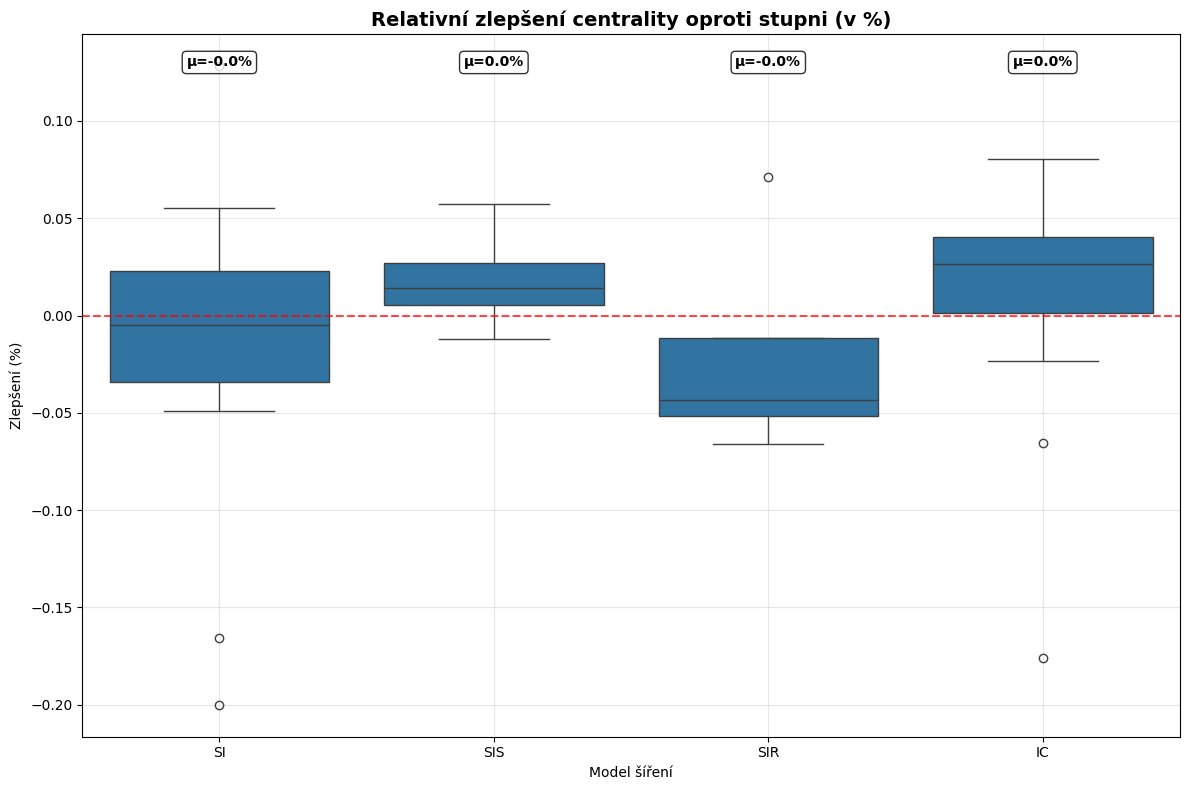

In [106]:
models_data = [('SI', si_df), ('SIS', sis_df), ('SIR', sir_df), ('IC', ic_df)]

fig, ax = plt.subplots(figsize=(12, 8))

improvement_data = []
for model_name, df in models_data:
    for _, row in df.iterrows():
        if row['method'] == 'centrality':
            # Find corresponding degree method result
            degree_row = df[(df['beta'] == row['beta']) & 
                          (df['num_initial_nodes'] == row['num_initial_nodes']) & 
                          (df['method'] == 'degree')]
            if not degree_row.empty:
                improvement = ((row['mean'] - degree_row['mean'].iloc[0]) / degree_row['mean'].iloc[0]) * 100
                improvement_data.append({
                    'Model': model_name,
                    'Beta': row['beta'],
                    'Initial_Nodes': row['num_initial_nodes'],
                    'Improvement_%': improvement
                })

improvement_df = pd.DataFrame(improvement_data)

# Box plot of improvements by model
sns.boxplot(data=improvement_df, x='Model', y='Improvement_%', ax=ax)
ax.set_title('Relativní zlepšení centrality oproti stupni (v %)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model šíření')
ax.set_ylabel('Zlepšení (%)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)

# Add mean values as text
for i, model in enumerate(['SI', 'SIS', 'SIR', 'IC']):
    model_data = improvement_df[improvement_df['Model'] == model]['Improvement_%']
    mean_val = model_data.mean()
    ax.text(i, ax.get_ylim()[1] * 0.9, f'μ={mean_val:.1f}%', 
           ha='center', va='center', fontweight='bold', 
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'relative_improvement_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


### IC Model - Efektivita versus počet uzlů (detailní rozklad)


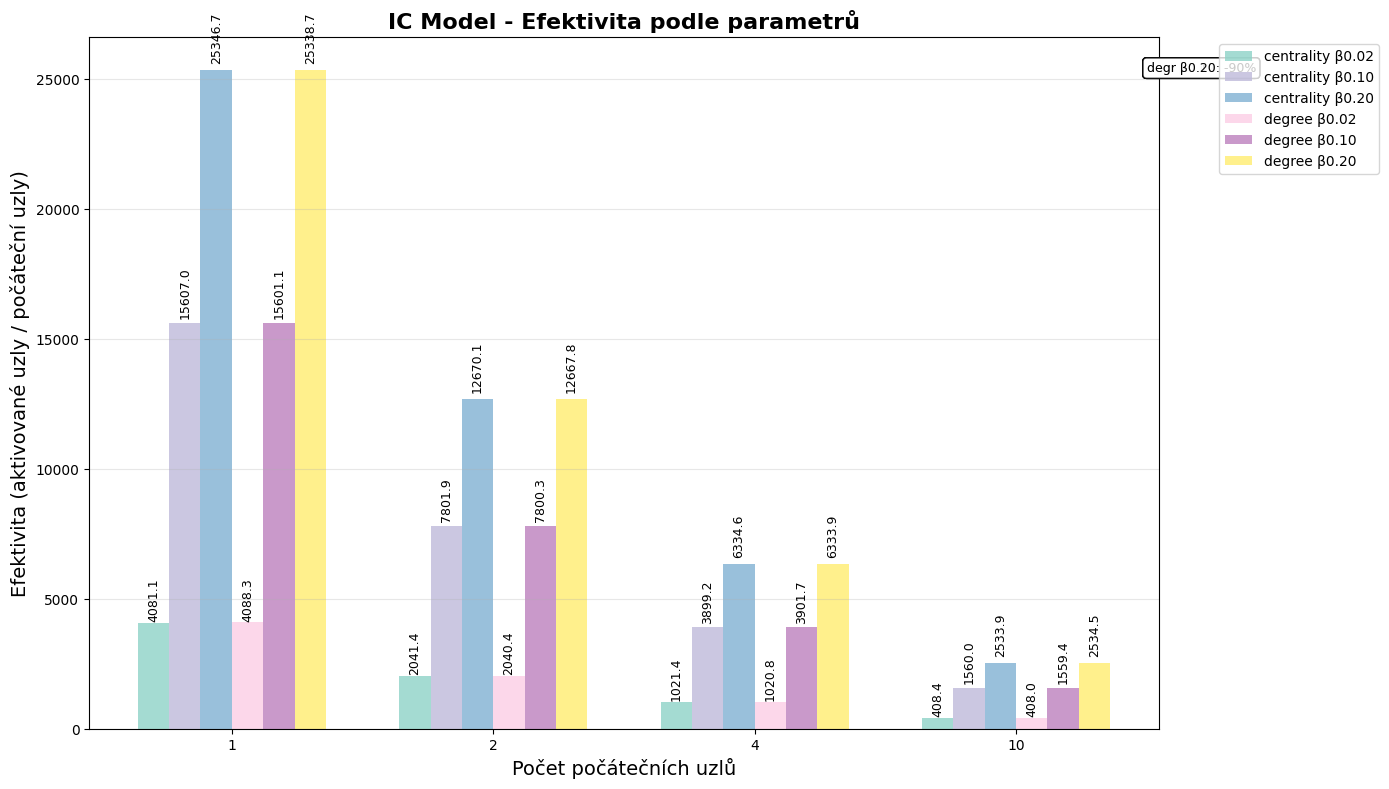

In [107]:
fig, ax = plt.subplots(figsize=(14, 8))

# Create comprehensive efficiency analysis
efficiency_data = []
for _, row in ic_df.iterrows():
    efficiency = row['mean'] / row['num_initial_nodes']
    efficiency_data.append({
        'Beta': row['beta'],
        'Method': row['method'], 
        'Num_Init': row['num_initial_nodes'],
        'Efficiency': efficiency,
        'Absolute_Reach': row['mean'],
        'Method_Beta': f"{row['method']}_β{row['beta']:.2f}"
    })

efficiency_df = pd.DataFrame(efficiency_data)

# Create grouped bar plot
methods_betas = efficiency_df['Method_Beta'].unique()
x_positions = np.arange(len(sorted(ic_df['num_initial_nodes'].unique())))
width = 0.12
colors = plt.cm.Set3(np.linspace(0, 1, len(methods_betas))) # type: ignore

for i, mb in enumerate(methods_betas):
    mb_data = efficiency_df[efficiency_df['Method_Beta'] == mb].sort_values('Num_Init')
    positions = x_positions + (i - len(methods_betas)/2 + 0.5) * width
    
    bars = ax.bar(positions, mb_data['Efficiency'], width, 
                 label=mb.replace('_', ' '), alpha=0.8, color=colors[i])
    
    # Add value labels on bars
    for bar, eff in zip(bars, mb_data['Efficiency']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mb_data['Efficiency'])*0.01,
               f'{eff:.1f}', ha='center', va='bottom', fontsize=9, rotation=90)

ax.set_title('IC Model - Efektivita podle parametrů', fontsize=16, fontweight='bold')
ax.set_xlabel('Počet počátečních uzlů', fontsize=14)
ax.set_ylabel('Efektivita (aktivované uzly / počáteční uzly)', fontsize=14)
ax.set_xticks(x_positions)
ax.set_xticklabels(sorted(ic_df['num_initial_nodes'].unique()))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add efficiency decline annotations
for method in ['centrality', 'degree']:
    for beta in sorted(ic_df['beta'].unique()):
        method_beta_data = efficiency_df[
            (efficiency_df['Method'] == method) & 
            (efficiency_df['Beta'] == beta)
        ].sort_values('Num_Init')
        
        if len(method_beta_data) > 1:
            first_eff = method_beta_data['Efficiency'].iloc[0]
            last_eff = method_beta_data['Efficiency'].iloc[-1]
            decline = ((first_eff - last_eff) / first_eff) * 100
            
            # Add decline annotation
            x_pos = len(sorted(ic_df['num_initial_nodes'].unique())) - 0.5
            y_pos = ax.get_ylim()[1] * 0.95
            ax.annotate(f'{method[:4]} β{beta:.2f}: -{decline:.0f}%', 
                       xy=(x_pos, y_pos), fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(PLOTS_SAVE_PATH / 'ic_model_efficiency_detailed.png', dpi=300, bbox_inches='tight')
plt.show()